# AI for Communication and Marketing  
## Lab Exam – Part 1

**Academic Year:** 2025/2026  
**Course:** B.Sc. in Artificial Intelligence  
**Student:** Marta Paniconi  
**Student ID:** 535358

---------------------

## Business Scenario

A retail company wants to use two years of customer data to improve targeting and communication.

This notebook develops an end-to-end customer analytics workflow: data quality assessment, exploratory analysis, RFM segmentation, clustering, and final communication recommendations.

The objective is to identify high-value customer segments and translate the findings into actionable marketing strategies.

---------------------

## TASK A — Data Audit & Quality

This section audits the dataset before any segmentation or campaign analysis.  
The goal is to verify structure, data types, missing values, duplicates, consistency issues and outliers.

### A.1 Load libraries and dataset

We first load the dataset and inspect its structure to understand the available customer, purchase and campaign variables.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# The dataset uses semicolon separators; utf-8-sig prevents hidden BOM issues
df = pd.read_csv("marketing_campaign.csv", sep=";", encoding="utf-8-sig")

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

initial_overview = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum().values,
    "Missing %": (df.isna().sum().values / len(df) * 100).round(2)
})

display(initial_overview)

display(df.describe(include="all").T)

Dataset loaded: 2,240 rows × 27 columns


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


,Column,Data Type,Missing Values,Missing %
ID,ID,int64,0,0.00
Year_Birth,Year_Birth,int64,0,0.00
Education,Education,str,0,0.00
Marital_Status,Marital_Status,str,0,0.00
Income,Income,float64,24,1.07
Kidhome,Kidhome,int64,0,0.00
Teenhome,Teenhome,int64,0,0.00
Dt_Customer,Dt_Customer,str,0,0.00
Recency,Recency,int64,0,0.00
MntWines,MntWines,int64,0,0.00


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,11.984069,1893.0,1959.0,1970.0,1977.0,1996.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.0,666666.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Dt_Customer,2240,663,2012-08-31,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2240.0,NaN,NaN,NaN,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0


- The dataset contains **2,240 customers** and **27 variables**, covering demographics, purchase behavior, product spending, purchase channels and campaign responses.
- `Income` is the only variable with missing values: **24 missing values**, equal to **1.07%** of the dataset.
- `Dt_Customer` is currently stored as a text variable, so it must be converted to datetime before computing customer tenure or time-based features.
- The initial statistics already highlight two quality points to investigate further: very old birth years, such as **1893**, and an extreme `Income` maximum of **666,666**.

### A.2 Data type audit

Before cleaning, we verify whether each variable is stored in the correct format.  
This is especially important for dates, binary campaign variables and categorical labels, because wrong formats can distort later segmentation and response analysis.

In [11]:
# A compact table makes original data types easier to inspect before transformations
type_audit_before = pd.DataFrame({
    "Column": df.columns,
    "Data Type Before Conversion": df.dtypes.astype(str)
})

display(type_audit_before)

# Date conversion is needed for tenure and time-based customer features
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")

date_audit = pd.DataFrame({
    "Check": [
        "Dt_Customer dtype after conversion",
        "Minimum registration date",
        "Maximum registration date",
        "Invalid parsed dates"
    ],
    "Result": [
        str(df["Dt_Customer"].dtype),
        df["Dt_Customer"].min(),
        df["Dt_Customer"].max(),
        df["Dt_Customer"].isna().sum()
    ]
})

display(date_audit)

# Binary campaign variables must contain only valid 0/1 values
binary_cols = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5", "Complain", "Response"
]

binary_audit = pd.DataFrame({
    "Variable": binary_cols,
    "Unique Values": [
        sorted(df[col].dropna().unique().tolist()) for col in binary_cols
    ],
    "Valid Binary Flag": [
        set(df[col].dropna().unique()).issubset({0, 1}) for col in binary_cols
    ]
})

display(binary_audit)

# Category counts reveal rare labels that may need grouping during cleaning
education_counts = (
    df["Education"]
    .value_counts()
    .rename_axis("Education")
    .reset_index(name="Count")
)

marital_counts = (
    df["Marital_Status"]
    .value_counts()
    .rename_axis("Marital_Status")
    .reset_index(name="Count")
)

display(education_counts)
display(marital_counts)

,Column,Data Type Before Conversion
ID,ID,int64
Year_Birth,Year_Birth,int64
Education,Education,str
Marital_Status,Marital_Status,str
Income,Income,float64
Kidhome,Kidhome,int64
Teenhome,Teenhome,int64
Dt_Customer,Dt_Customer,datetime64[us]
Recency,Recency,int64
MntWines,MntWines,int64


,Check,Result
0,Dt_Customer dtype after conversion,datetime64[us]
1,Minimum registration date,2012-07-30 00:00:00
2,Maximum registration date,2014-06-29 00:00:00
3,Invalid parsed dates,0


,Variable,Unique Values,Valid Binary Flag
0,AcceptedCmp1,"[0, 1]",True
1,AcceptedCmp2,"[0, 1]",True
2,AcceptedCmp3,"[0, 1]",True
3,AcceptedCmp4,"[0, 1]",True
4,AcceptedCmp5,"[0, 1]",True
5,Complain,"[0, 1]",True
6,Response,"[0, 1]",True


,Education,Count
0,Graduation,1127
1,PhD,486
2,Master,370
3,2n Cycle,203
4,Basic,54


,Marital_Status,Count
0,Married,864
1,Together,580
2,Single,480
3,Divorced,232
4,Widow,77
5,Alone,3
6,Absurd,2
7,YOLO,2


- `Dt_Customer` was successfully converted from text to datetime, enabling reliable tenure and time-based feature engineering.
- The registration dates are valid, with **0 invalid parsed dates** after conversion.
- All campaign and response variables contain only valid **0/1** values, so they can be safely used for campaign-response analysis.
- `Education` contains clear categories, while `Marital_Status` includes rare labels such as `Alone`, `Absurd` and `YOLO`; these will be grouped into `Other` during cleaning.

### A.3 Missing values audit

Missing values must be quantified before choosing between deletion and imputation.  
Here, the goal is to understand whether missingness is limited enough to preserve customers for later segmentation.

,Missing Count,Missing %
Income,24,1.07


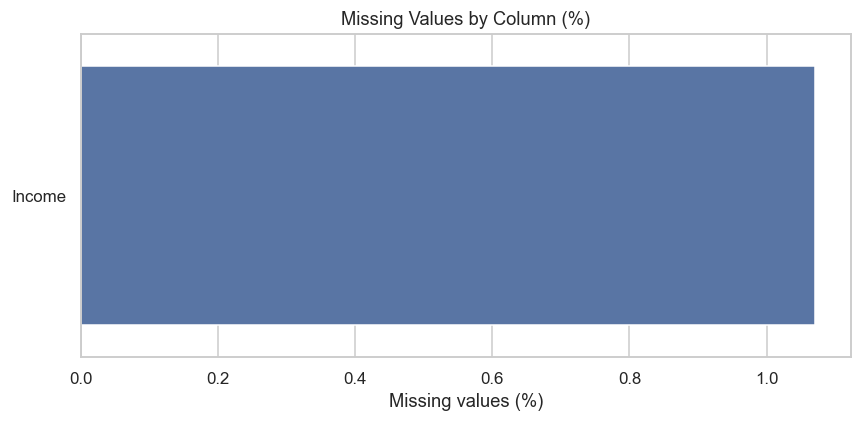

In [12]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().sum() / len(df) * 100).round(2)
})

# Only columns with missing values are relevant for this audit
missing_summary = (
    missing_summary[missing_summary["Missing Count"] > 0]
    .sort_values("Missing %", ascending=False)
)

display(missing_summary)

# The chart is shown only if missing values exist
if not missing_summary.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=missing_summary.reset_index(names="Column"),
        x="Missing %",
        y="Column"
    )
    plt.title("Missing Values by Column (%)")
    plt.xlabel("Missing values (%)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

- Only `Income` contains missing values: **24 customers**, equal to **1.07%** of the dataset.
- Since the missing share is very small, removing these customers would be unnecessary and could reduce useful information for segmentation.
- `Income` is important for customer profiling and marketing targeting, so it will be imputed rather than dropped.
- The cleaning step will use a robust median-based imputation strategy to preserve customers while limiting distortion from income skewness.

### A.4 Duplicate audit

Duplicates can distort customer counts, spending totals and campaign response metrics.  
We check both full duplicated rows and repeated customer IDs, because the analysis is performed at customer level.

In [13]:
# Full duplicates would inflate all customer-level metrics
full_duplicates = df.duplicated().sum()

# Repeated IDs would indicate that the same customer appears more than once
id_duplicates = df["ID"].duplicated().sum()

duplicate_summary = pd.DataFrame({
    "Check": ["Full duplicated rows", "Duplicated customer IDs"],
    "Count": [full_duplicates, id_duplicates]
})

display(duplicate_summary)

if id_duplicates > 0:
    duplicated_ids = (
        df.loc[df["ID"].duplicated(keep=False), "ID"]
        .value_counts()
        .reset_index()
    )
    duplicated_ids.columns = ["ID", "Occurrences"]
    display(duplicated_ids)

,Check,Count
0,Full duplicated rows,0
1,Duplicated customer IDs,0


- The dataset contains **0 full duplicated rows**, so no complete records are repeated.
- The dataset contains **0 duplicated customer IDs**, confirming that each row represents one unique customer.
- No duplicate removal is needed before segmentation or campaign analysis.

### A.4 Business consistency checks

This step checks whether some values are not plausible from a business perspective.  
Unlike statistical outliers, these issues may indicate data-entry errors, such as unrealistic ages, negative purchases or impossible spending values.

In [18]:
# Age is anchored to the data collection period, not to the current year
reference_year = df["Dt_Customer"].dt.year.max()
df["Age"] = reference_year - df["Year_Birth"]

spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

purch_cols = [
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth"
]

# Business consistency checks identify impossible or suspicious values
age_over_100 = (df["Age"] > 100).sum()
age_under_18 = (df["Age"] < 18).sum()
income_missing = df["Income"].isna().sum()
income_non_positive = (df["Income"] <= 0).sum()
income_extreme = (df["Income"] > 200000).sum()
negative_spending_rows = (df[spend_cols] < 0).any(axis=1).sum()
negative_purchase_rows = (df[purch_cols] < 0).any(axis=1).sum()
recency_invalid = ((df["Recency"] < 0) | (df["Recency"] > 365)).sum()

consistency_issues = pd.DataFrame({
    "Issue": [
        "Age > 100",
        "Age < 18",
        "Income missing",
        "Income <= 0",
        "Income > 200000",
        "Negative spending values",
        "Negative purchase/activity values",
        "Recency outside [0, 365]"
    ],
    "Affected Rows": [
        age_over_100,
        age_under_18,
        income_missing,
        income_non_positive,
        income_extreme,
        negative_spending_rows,
        negative_purchase_rows,
        recency_invalid
    ]
})

display(consistency_issues)

range_summary = pd.DataFrame({
    "Variable": ["Age", "Income", "Recency"],
    "Minimum": [df["Age"].min(), df["Income"].min(), df["Recency"].min()],
    "Maximum": [df["Age"].max(), df["Income"].max(), df["Recency"].max()]
})

display(range_summary)

,Issue,Affected Rows
0,Age > 100,3
1,Age < 18,0
2,Income missing,24
3,Income <= 0,0
4,Income > 200000,1
5,Negative spending values,0
6,Negative purchase/activity values,0
7,"Recency outside [0, 365]",0


,Variable,Minimum,Maximum
0,Age,18.0,121.0
1,Income,1730.0,666666.0
2,Recency,0.0,99.0


- **3 customers have Age > 100**, which is likely due to data-entry errors and will be removed during cleaning.
- **1 customer has Income > 200,000**, with a maximum value of **666,666**; this will be treated as missing before imputation.
- Spending, purchase/activity variables and `Recency` contain **0 invalid negative values**, so no correction is needed for these fields.

### A.6 Outlier detection

After checking business-impossible values, we identify statistical outliers using the IQR method.  
In marketing data, outliers are not automatically errors: high spending can represent valuable customers, while extreme demographic values may require correction.

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,N_Outliers,Pct_Outliers
7,MntSweetProducts,1.00,33.00,32.0,-47.0,81.0,248,11.07
4,MntFruits,1.00,33.00,32.0,-47.0,81.0,227,10.13
6,MntFishProducts,3.00,50.00,47.0,-67.5,120.5,223,9.96
8,MntGoldProds,9.00,56.00,47.0,-61.5,126.5,207,9.24
5,MntMeatProducts,16.00,232.00,216.0,-308.0,556.0,175,7.81
9,NumDealsPurchases,1.00,3.00,2.0,-2.0,6.0,86,3.84
3,MntWines,23.75,504.25,480.5,-697.0,1225.0,35,1.56
11,NumCatalogPurchases,0.00,4.00,4.0,-6.0,10.0,23,1.03
1,Income,35303.00,68522.00,33219.0,-14525.5,118350.5,8,0.36
13,NumWebVisitsMonth,3.00,7.00,4.0,-3.0,13.0,8,0.36


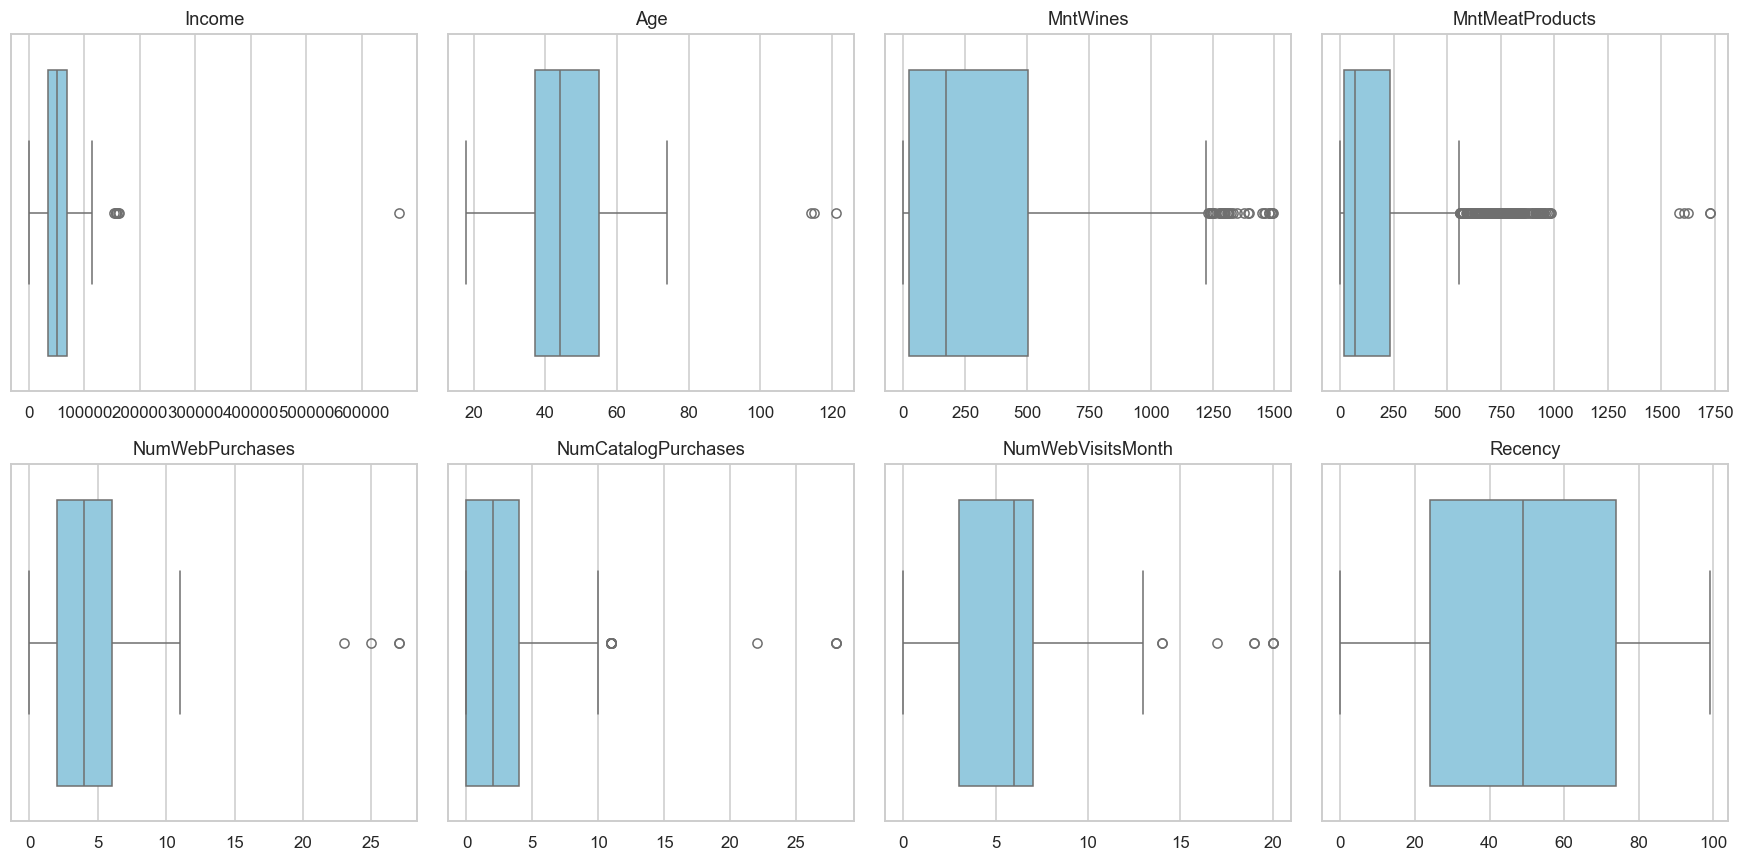

In [19]:
key_cols = ['Age', 'Income', 'Recency'] + spend_cols + purch_cols
rows = []
for col in key_cols:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((s < lower) | (s > upper)).sum()
    pct_out = n_out / len(s) * 100
    rows.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower,
        'Upper_Bound': upper,
        'N_Outliers': n_out,
        'Pct_Outliers': round(pct_out, 2)
    })
outlier_summary = (
    pd.DataFrame(rows)
    .sort_values('Pct_Outliers', ascending=False)
)
display(outlier_summary)

# 1.5×IQR flags extreme values without committing to removal.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
plot_cols = ['Income', 'Age', 'MntWines', 'MntMeatProducts',
             'NumWebPurchases', 'NumCatalogPurchases',
             'NumWebVisitsMonth', 'Recency']
for ax, col in zip(axes.flatten(), plot_cols):
    sns.boxplot(x=df[col], ax=ax, color='skyblue')
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

- The IQR method mainly flags outliers in product spending variables, especially `MntSweetProducts` (**11.07%**), `MntFruits` (**10.13%**), `MntFishProducts` (**9.96%**), `MntGoldProds` (**9.24%**) and `MntMeatProducts` (**7.81%**). This confirms that customer spending is strongly right-skewed.

    These spending outliers should be preserved: in a marketing context, unusually high purchases are not necessarily errors, but may represent high-value customers that are important for segmentation and campaign targeting.

- `NumDealsPurchases` also shows some extreme values (**3.84%**), suggesting the presence of a small group of highly discount-oriented customers.

- `Income` has only a few statistical outliers (**0.36%**), but the extreme maximum value above **200,000** is not reliable for customer profiling and will be corrected during cleaning. `Recency` shows **0 outliers**, so no treatment is needed for this variable.

### A.7 Cleaning strategy

Based on the audit, the cleaning strategy is selective: only values that are clearly implausible are corrected, while meaningful customer behavior is preserved.

- **Implausible ages:** customers with `Age > 100` are removed because these values are likely data-entry errors and could distort demographic analysis.
- **Missing and extreme Income:** `Income` has 24 missing values and 1 extreme value above 200,000. The extreme value is treated as unreliable, converted to missing, and then imputed together with the original missing values.
- **Income imputation:** missing `Income` values are imputed using the median income within each `Education` group, because education is a reasonable socio-economic proxy and the median is robust to skewness.
- **Rare marital labels:** unusual `Marital_Status` labels such as `Alone`, `Absurd` and `YOLO` are grouped into `Other` to avoid fragmented categories in later analysis.
- **Spending outliers:** product spending outliers are preserved because high spending may represent valuable customers, not data errors.
- **Duplicates and invalid negatives:** no duplicate customer IDs, negative spending values, negative purchase counts or invalid recency values were found, so no correction is needed for these fields.

The final cleaned dataframe will be stored as `df_clean` and used for all subsequent analyses.

In [20]:
df_raw = df.copy()

df_clean = df.copy()
log = []

# Implausible ages are likely data-entry errors, not meaningful customer profiles
n_before = len(df_clean)
df_clean = df_clean[(df_clean["Age"] <= 100) & (df_clean["Age"] >= 18)].copy()
n_removed_age = n_before - len(df_clean)

log.append({
    "Issue": "Implausible Age",
    "Action": "Drop rows with Age > 100 or Age < 18",
    "Reason": "Implausible age values are likely data-entry errors and could distort demographic analysis",
    "Rows_Affected": n_removed_age
})

# Extreme income is treated as unreliable before imputation
n_extreme_income = (df_clean["Income"] > 200000).sum()
original_missing_income = df_clean["Income"].isna().sum()

df_clean.loc[df_clean["Income"] > 200000, "Income"] = np.nan

log.append({
    "Issue": "Income > 200,000",
    "Action": "Set to NaN before imputation",
    "Reason": "Extreme income values may distort socio-economic segmentation",
    "Rows_Affected": int(n_extreme_income)
})

# Median imputation is robust to skewness and preserves customers for segmentation
total_income_to_impute = df_clean["Income"].isna().sum()

df_clean["Income"] = (
    df_clean
    .groupby("Education")["Income"]
    .transform(lambda s: s.fillna(s.median()))
)

# Global median is a safe fallback if any education group has no valid income values
global_income_median = df_clean["Income"].median()
df_clean["Income"] = df_clean["Income"].fillna(global_income_median)

log.append({
    "Issue": "Missing or flagged Income",
    "Action": "Impute with median by Education group",
    "Reason": "Education is a reasonable socio-economic proxy, and median imputation limits the effect of skewness",
    "Rows_Affected": int(total_income_to_impute)
})

# Rare labels are grouped to avoid fragmented categories in later analysis
rare_labels = ["Alone", "Absurd", "YOLO"]
n_rare = df_clean["Marital_Status"].isin(rare_labels).sum()

df_clean["Marital_Status"] = df_clean["Marital_Status"].replace(rare_labels, "Other")

log.append({
    "Issue": "Rare Marital_Status labels",
    "Action": "Group Alone, Absurd and YOLO into Other",
    "Reason": "Grouping preserves customers while reducing categorical noise",
    "Rows_Affected": int(n_rare)
})

# High spending outliers are preserved because they may represent valuable customers
log.append({
    "Issue": "Product spending outliers",
    "Action": "Preserve values",
    "Reason": "High spenders are meaningful for customer value analysis and segmentation",
    "Rows_Affected": "N/A"
})

cleaning_log = pd.DataFrame(log)

print(f"Original rows: {len(df_raw)}")
print(f"Cleaned rows:  {len(df_clean)}")
print(f"Rows removed:  {len(df_raw) - len(df_clean)}")
print(f"Original missing Income after age cleaning: {original_missing_income}")
print(f"Extreme Income values flagged: {n_extreme_income}")
print(f"Total Income values imputed: {total_income_to_impute}")
print(f"Income missing after imputation: {df_clean['Income'].isna().sum()}")
print(f"Max Age after cleaning: {df_clean['Age'].max()}")
print(f"Min Age after cleaning: {df_clean['Age'].min()}")
print(f"Income > 200,000 after cleaning: {(df_clean['Income'] > 200000).sum()}")

print("\nCleaned Marital_Status distribution:")
print(df_clean["Marital_Status"].value_counts())

display(cleaning_log)

Original rows: 2240
Cleaned rows:  2237
Rows removed:  3
Original missing Income after age cleaning: 24
Extreme Income values flagged: 1
Total Income values imputed: 25
Income missing after imputation: 0
Max Age after cleaning: 74
Min Age after cleaning: 18
Income > 200,000 after cleaning: 0

Cleaned Marital_Status distribution:
Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Other         7
Name: count, dtype: int64


,Issue,Action,Reason,Rows_Affected
0,Implausible Age,Drop rows with Age > 100 or Age < 18,Implausible age values are likely data-entry e...,3
1,"Income > 200,000",Set to NaN before imputation,Extreme income values may distort socio-econom...,1
2,Missing or flagged Income,Impute with median by Education group,Education is a reasonable socio-economic proxy...,25
3,Rare Marital_Status labels,"Group Alone, Absurd and YOLO into Other",Grouping preserves customers while reducing ca...,7
4,Product spending outliers,Preserve values,High spenders are meaningful for customer valu...,N/A


- **3 customers were removed** because their age values were implausible and likely reflected data-entry errors.
- `Income` cleaning affected **25 values**: 24 originally missing values plus 1 extreme value above 200,000 converted to missing before imputation.
- Missing `Income` values were imputed using the median income within each `Education` group, preserving customers while limiting the effect of income skewness.
- Rare `Marital_Status` labels were grouped into `Other`, while product spending outliers were preserved because high spenders are meaningful for segmentation.

### A.8 Final quality check

After cleaning, we verify that the main data quality issues have been resolved.  
This final check ensures that `df_clean` can be safely used for exploratory analysis, segmentation and clustering.

In [22]:
# Final checks confirm that the cleaned dataset is ready for analysis
final_quality_check = pd.DataFrame({
    "Check": [
        "Rows in raw dataset",
        "Rows in cleaned dataset",
        "Rows removed",
        "Remaining missing values",
        "Duplicated customer IDs",
        "Age > 100",
        "Age < 18",
        "Income > 200,000",
        "Invalid negative Recency"
    ],
    "Result": [
        len(df_raw),
        len(df_clean),
        len(df_raw) - len(df_clean),
        df_clean.isna().sum().sum(),
        df_clean["ID"].duplicated().sum(),
        (df_clean["Age"] > 100).sum(),
        (df_clean["Age"] < 18).sum(),
        (df_clean["Income"] > 200000).sum(),
        (df_clean["Recency"] < 0).sum()
    ]
})

display(final_quality_check)

# Category distribution confirms that rare marital labels were grouped correctly
marital_distribution = (
    df_clean["Marital_Status"]
    .value_counts()
    .rename_axis("Marital_Status")
    .reset_index(name="Count")
)

display(marital_distribution)

,Check,Result
0,Rows in raw dataset,2240
1,Rows in cleaned dataset,2237
2,Rows removed,3
3,Remaining missing values,0
4,Duplicated customer IDs,0
5,Age > 100,0
6,Age < 18,0
7,"Income > 200,000",0
8,Invalid negative Recency,0


,Marital_Status,Count
0,Married,864
1,Together,579
2,Single,479
3,Divorced,231
4,Widow,77
5,Other,7


- `df_clean` contains **2,237 customers**, after removing **3 implausible age records** from the original dataset.
- No missing values remain after `Income` imputation, and no duplicated customer IDs are present.
- No unresolved critical issues remain: there are **0 invalid ages**, **0 Income values above 200,000** and **0 negative Recency values**.
- Task A is complete: `df_clean` is ready for Task B, with spending outliers intentionally preserved because they may represent valuable customers.

-------------------

## Task B — Exploratory Data Analysis (EDA)

This task explores the cleaned customer dataset to identify the main drivers of spending, purchase-channel preferences and potential campaign opportunities.

The analysis focuses on three questions:
- Which customer characteristics are associated with higher `Total_Spending`?
- How are purchases distributed across web, catalog and store channels?
- Is there a hidden customer pattern that can support a targeted promotional campaign?

The working dataframe for this task is `df_eda`, created from `df_clean`.

In [23]:
df_eda = df_clean.copy()

print(f"EDA dataframe: {df_eda.shape[0]:,} rows × {df_eda.shape[1]} columns")

EDA dataframe: 2,237 rows × 28 columns


### B.1 Feature engineering for EDA

Before analyzing spending and campaign behavior, we create customer-level variables that summarize value, purchase activity, family composition, tenure, campaign engagement, product mix and channel mix.

In [24]:
# Product spending columns are aggregated to measure total customer value

df_eda["Total_Spending"] = df_eda[spend_cols].sum(axis=1)

# Purchase channels are aggregated to measure buying frequency

df_eda["Total_Purchases"] = df_eda[purchase_cols].sum(axis=1)

# Family composition is relevant for lifestyle-based targeting
df_eda["Children"] = df_eda["Kidhome"] + df_eda["Teenhome"]
df_eda["Has_Children"] = (df_eda["Children"] > 0).astype(int)

# Customer tenure captures how long the customer has been in the database
max_date = df_eda["Dt_Customer"].max()
df_eda["Customer_Tenure_Days"] = (max_date - df_eda["Dt_Customer"]).dt.days

# Previous campaign acceptance is separated from the latest campaign response
previous_campaign_cols = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5"
]

df_eda["Previous_Campaign_Accepted"] = (
    df_eda[previous_campaign_cols].sum(axis=1) > 0
).astype(int)

df_eda["Total_Accepted_Campaigns"] = df_eda[previous_campaign_cols + ["Response"]].sum(axis=1)

# Standardized product share names avoid inconsistencies in later tasks
product_share_map = {
    "MntWines": "Wine_Share",
    "MntFruits": "Fruit_Share",
    "MntMeatProducts": "Meat_Share",
    "MntFishProducts": "Fish_Share",
    "MntSweetProducts": "Sweet_Share",
    "MntGoldProds": "Gold_Share"
}

for original_col, share_col in product_share_map.items():
    df_eda[share_col] = np.where(
        df_eda["Total_Spending"] > 0,
        df_eda[original_col] / df_eda["Total_Spending"],
        0
    )

# Channel shares show relative preference, not just absolute purchase volume
channel_share_map = {
    "NumWebPurchases": "Web_Share",
    "NumCatalogPurchases": "Catalog_Share",
    "NumStorePurchases": "Store_Share"
}

for original_col, share_col in channel_share_map.items():
    df_eda[share_col] = np.where(
        df_eda["Total_Purchases"] > 0,
        df_eda[original_col] / df_eda["Total_Purchases"],
        0
    )

engineered_features = [
    "Total_Spending", "Total_Purchases", "Children", "Has_Children",
    "Customer_Tenure_Days", "Previous_Campaign_Accepted",
    "Total_Accepted_Campaigns",
    "Wine_Share", "Fruit_Share", "Meat_Share", "Fish_Share",
    "Sweet_Share", "Gold_Share",
    "Web_Share", "Catalog_Share", "Store_Share"
]

display(df_eda[engineered_features].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
Total_Spending,2237.0,605.74,601.84,5.0,69.00,396.00,1045.00,2525.00
Total_Purchases,2237.0,20.19,7.29,0.0,14.00,19.00,25.00,46.00
Children,2237.0,0.95,0.75,0.0,0.00,1.00,1.00,3.00
Has_Children,2237.0,0.72,0.45,0.0,0.00,1.00,1.00,1.00
Customer_Tenure_Days,2237.0,353.79,202.14,0.0,181.00,356.00,529.00,699.00
Previous_Campaign_Accepted,2237.0,0.21,0.40,0.0,0.00,0.00,0.00,1.00
Total_Accepted_Campaigns,2237.0,0.45,0.89,0.0,0.00,0.00,1.00,5.00
Wine_Share,2237.0,0.46,0.23,0.0,0.29,0.46,0.64,0.96
Fruit_Share,2237.0,0.05,0.06,0.0,0.01,0.03,0.07,0.45
Meat_Share,2237.0,0.25,0.13,0.0,0.16,0.23,0.33,1.00


- The average `Total_Spending` is **605.74**, while the median is **396.00**, confirming that spending is right-skewed: a smaller group of customers spends much more than the typical customer.
- Customers make on average **20.19 purchases**, with a median of **19**, so purchase activity is relatively substantial across the customer base.
- Around **72% of customers have children in the household**, making family composition an important variable to test in the spending and response analysis.
- Product shares show that `Wine_Share` is the dominant category on average (**46%**), followed by `Meat_Share` (**25%**), while store purchases represent the largest average channel share.

### B.2 Socio-demographic profile

Before analyzing what drives spending, we first describe the customer base.  
This helps contextualize later results by showing the distribution of age, income, education, marital status and household composition.

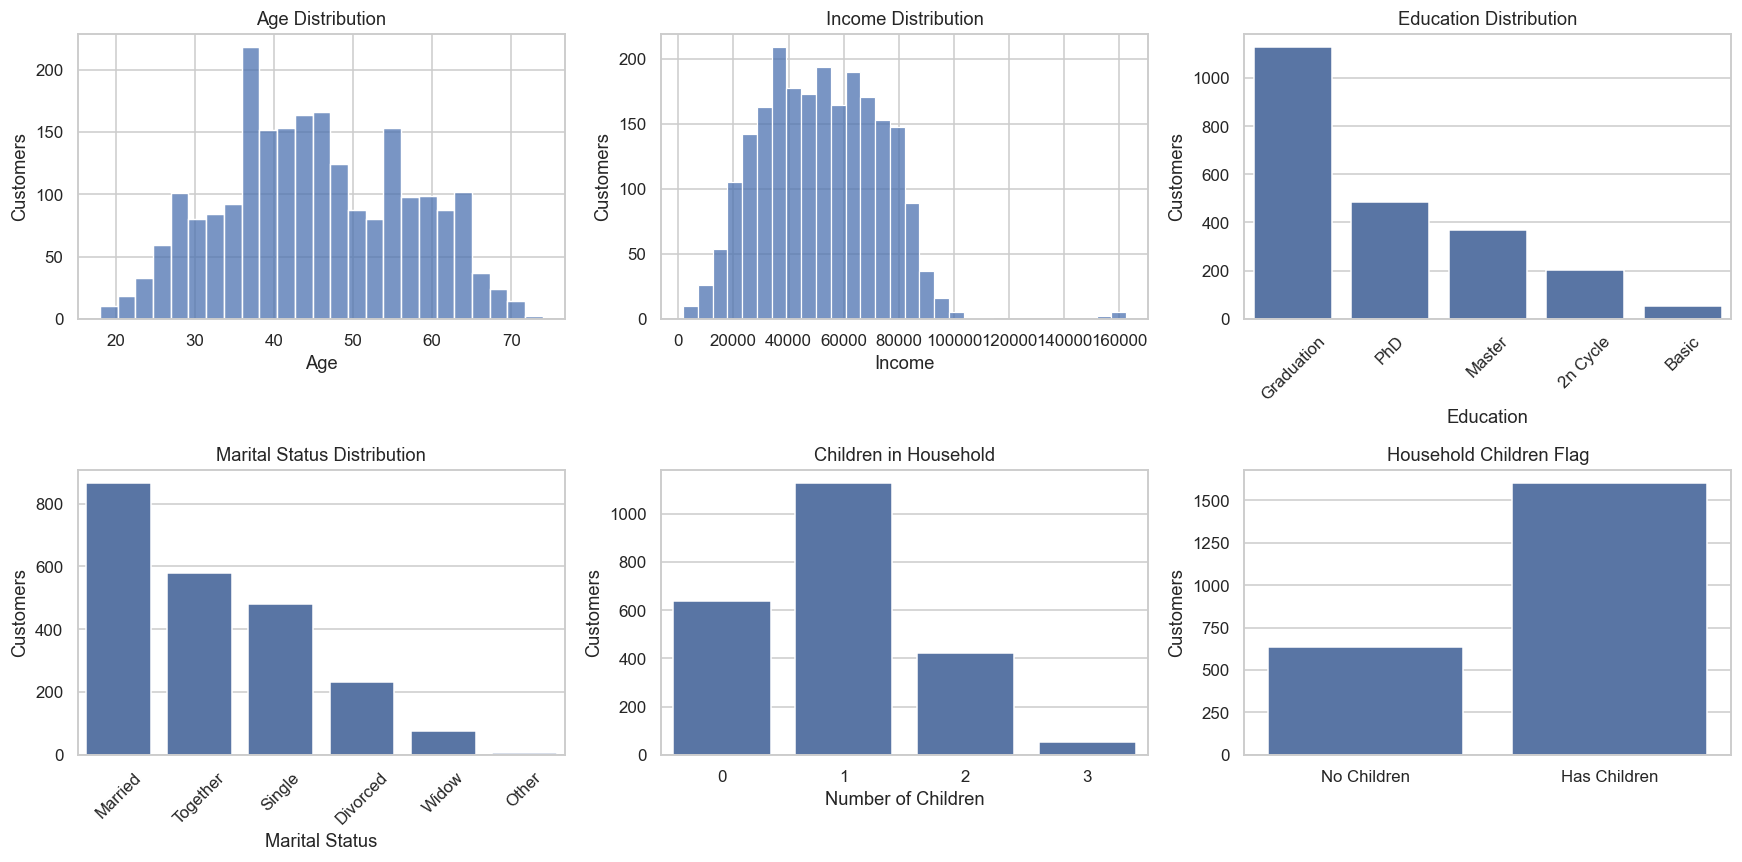

,Metric,Value
0,Average Age,45.10
1,Median Age,44.00
2,Average Income,51956.97
3,Median Income,51479.00
4,Share with Children,0.72


In [26]:
# Socio-demographic variables help describe the structure of the customer base
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.histplot(df_eda["Age"], bins=25, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Customers")

sns.histplot(df_eda["Income"], bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Income Distribution")
axes[0, 1].set_xlabel("Income")
axes[0, 1].set_ylabel("Customers")

education_order = df_eda["Education"].value_counts().index
sns.countplot(data=df_eda, x="Education", order=education_order, ax=axes[0, 2])
axes[0, 2].set_title("Education Distribution")
axes[0, 2].set_xlabel("Education")
axes[0, 2].set_ylabel("Customers")
axes[0, 2].tick_params(axis="x", rotation=45)

marital_order = df_eda["Marital_Status"].value_counts().index
sns.countplot(data=df_eda, x="Marital_Status", order=marital_order, ax=axes[1, 0])
axes[1, 0].set_title("Marital Status Distribution")
axes[1, 0].set_xlabel("Marital Status")
axes[1, 0].set_ylabel("Customers")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.countplot(data=df_eda, x="Children", ax=axes[1, 1])
axes[1, 1].set_title("Children in Household")
axes[1, 1].set_xlabel("Number of Children")
axes[1, 1].set_ylabel("Customers")

has_children_counts = df_eda["Has_Children"].map({0: "No Children", 1: "Has Children"})
sns.countplot(x=has_children_counts, ax=axes[1, 2])
axes[1, 2].set_title("Household Children Flag")
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Customers")

plt.tight_layout()
plt.show()

socio_summary = pd.DataFrame({
    "Metric": [
        "Average Age",
        "Median Age",
        "Average Income",
        "Median Income",
        "Share with Children"
    ],
    "Value": [
        df_eda["Age"].mean(),
        df_eda["Age"].median(),
        df_eda["Income"].mean(),
        df_eda["Income"].median(),
        df_eda["Has_Children"].mean()
    ]
})

display(socio_summary.round(2))

- Customers are mostly adults in the central age range of the dataset, with an average age of **45.10 years** and a median age of **44 years**.
- Average income is around **51,956.97**, with a median of **51,479**, suggesting a relatively balanced central income distribution after cleaning, although higher-income customers are still visible.
- The customer base is dominated by the `Graduation` education level, followed by `PhD` and `Master`, which indicates a relatively educated customer population.
- Most customers have children in the household: **72%** have at least one child. This makes family composition a key variable to test against spending and campaign response.

### B.3 Correlation with Total Spending

This section identifies which customer characteristics are most associated with `Total_Spending`.  
Socio-demographic variables are analyzed together with a few behavioral variables to distinguish customer profile effects from purchase-activity effects.

,Variable,Correlation_with_Total_Spending
0,Income,0.789
1,Total_Purchases,0.628
2,Total_Accepted_Campaigns,0.456
3,Customer_Tenure_Days,0.159
4,Age,0.114
5,Recency,0.021
6,NumDealsPurchases,-0.065
7,Teenhome,-0.138
8,Children,-0.499
9,NumWebVisitsMonth,-0.500


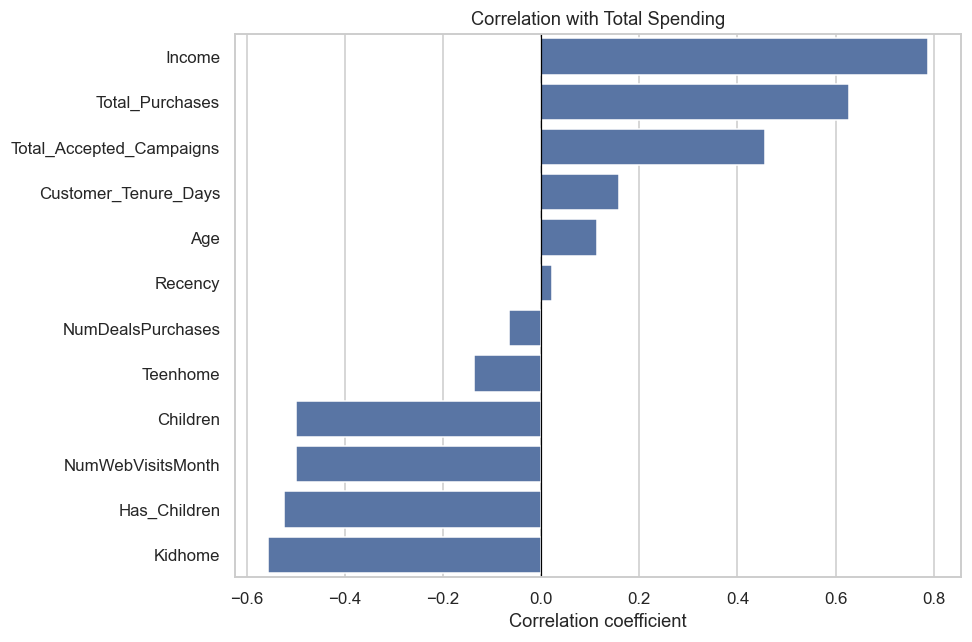

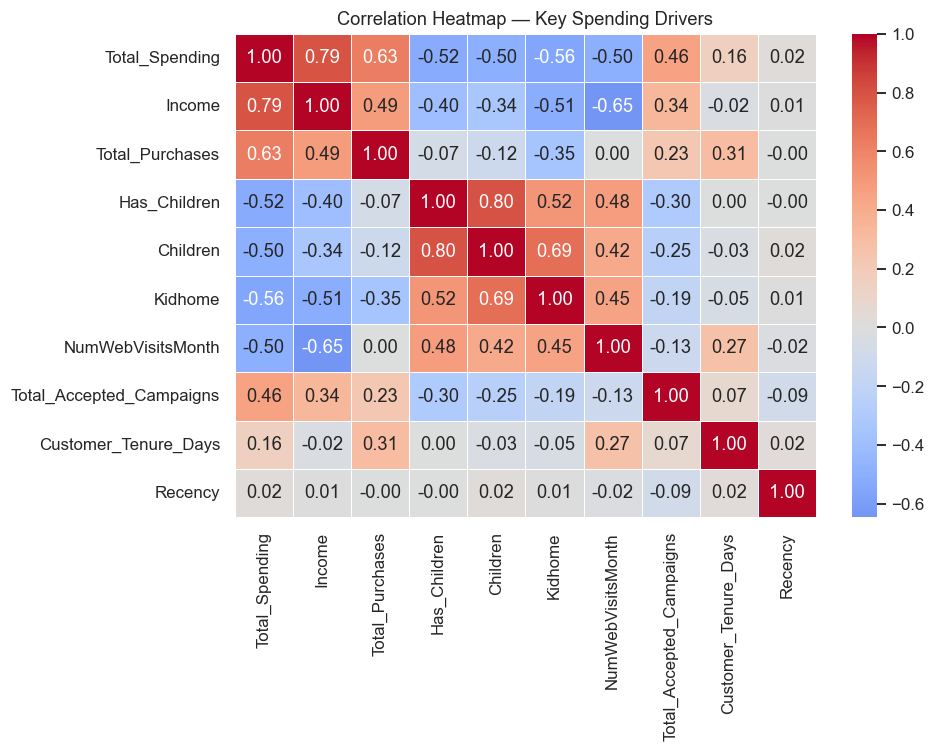

In [27]:
# These variables compare socio-demographic profile, digital behavior and purchase activity
correlation_features = [
    "Age",
    "Income",
    "Kidhome",
    "Teenhome",
    "Children",
    "Has_Children",
    "Customer_Tenure_Days",
    "Recency",
    "NumWebVisitsMonth",
    "NumDealsPurchases",
    "Total_Accepted_Campaigns",
    "Total_Purchases",
    "Total_Spending"
]

# Keep only available columns to avoid errors if a variable name changes
correlation_features = [col for col in correlation_features if col in df_eda.columns]

corr_matrix = df_eda[correlation_features].corr(numeric_only=True)

# The main requirement is the relationship with Total_Spending
spending_corr = (
    corr_matrix["Total_Spending"]
    .drop("Total_Spending")
    .sort_values(ascending=False)
    .reset_index()
)

spending_corr.columns = ["Variable", "Correlation_with_Total_Spending"]

display(spending_corr.round(3))

plt.figure(figsize=(9, 6))
sns.barplot(
    data=spending_corr,
    x="Correlation_with_Total_Spending",
    y="Variable"
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation with Total Spending")
plt.xlabel("Correlation coefficient")
plt.ylabel("")
plt.tight_layout()
plt.show()

# A compact heatmap supports interpretation of the most relevant relationships
heatmap_vars = [
    "Total_Spending",
    "Income",
    "Total_Purchases",
    "Has_Children",
    "Children",
    "Kidhome",
    "NumWebVisitsMonth",
    "Total_Accepted_Campaigns",
    "Customer_Tenure_Days",
    "Recency"
]

heatmap_vars = [col for col in heatmap_vars if col in df_eda.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(
    df_eda[heatmap_vars].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap — Key Spending Drivers")
plt.tight_layout()
plt.show()

- `Income` is the strongest positive variable associated with `Total_Spending`, with a correlation of **0.79**. This confirms that purchasing power is a major driver of customer value.
- `Total_Purchases` is also strongly associated with spending (**0.63**), showing that higher-value customers are generally more active buyers.
- Family-related variables are negatively associated with spending: `Kidhome` (**-0.56**), `Has_Children` (**-0.52**) and `Children` (**-0.50**) suggest that customers without children tend to spend more.
- `NumWebVisitsMonth` is negatively associated with spending (**-0.50**), meaning that frequent website visits do not necessarily indicate high value; they may reflect browsing without conversion.

### B.4 Spending and response by demographic groups

After identifying the main numerical correlations, we compare spending and campaign response across categorical demographic groups.  
This helps understand whether variables such as education, marital status and household composition can support targeted marketing decisions.

In [29]:
# A reusable function keeps demographic comparisons consistent across groups
def demographic_summary(df, group_col):
    summary = (
        df.groupby(group_col)
        .agg(
            Customer_Count=("ID", "count"),
            Avg_Total_Spending=("Total_Spending", "mean"),
            Median_Total_Spending=("Total_Spending", "median"),
            Avg_Income=("Income", "mean"),
            Response_Rate=("Response", "mean")
        )
        .reset_index()
    )

    # Response rate is easier to interpret as a percentage
    summary["Response_Rate_%"] = summary["Response_Rate"] * 100
    summary = summary.drop(columns="Response_Rate")

    return summary.round(2)


# Clear labels make household composition easier to interpret
df_eda["Household_Type"] = df_eda["Has_Children"].map({
    0: "No Children",
    1: "Has Children"
})

education_summary = demographic_summary(df_eda, "Education")
marital_summary = demographic_summary(df_eda, "Marital_Status")
household_summary = demographic_summary(df_eda, "Household_Type")

display(education_summary.sort_values("Avg_Total_Spending", ascending=False))
display(marital_summary.sort_values("Avg_Total_Spending", ascending=False))
display(household_summary.sort_values("Avg_Total_Spending", ascending=False))

,Education,Customer_Count,Avg_Total_Spending,Median_Total_Spending,Avg_Income,Response_Rate_%
4,PhD,485,669.98,493.0,56078.95,20.82
2,Graduation,1127,619.90,414.0,52167.76,13.49
3,Master,370,611.78,387.5,52890.85,15.41
0,2n Cycle,201,501.03,205.0,47613.09,10.95
1,Basic,54,81.80,57.0,20306.26,3.70


,Marital_Status,Customer_Count,Avg_Total_Spending,Median_Total_Spending,Avg_Income,Response_Rate_%
5,Widow,77,738.82,636.0,56409.62,24.68
0,Divorced,231,612.99,400.0,52904.33,20.78
3,Single,479,607.70,368.0,50997.29,22.13
4,Together,579,606.24,392.0,52105.74,10.36
1,Married,864,590.80,396.5,51728.49,11.34
2,Other,7,571.86,424.0,53280.29,42.86


,Household_Type,Customer_Count,Avg_Total_Spending,Median_Total_Spending,Avg_Income,Response_Rate_%
1,No Children,637,1104.86,1189.0,65563.50,26.53
0,Has Children,1600,407.03,198.0,46539.87,10.31


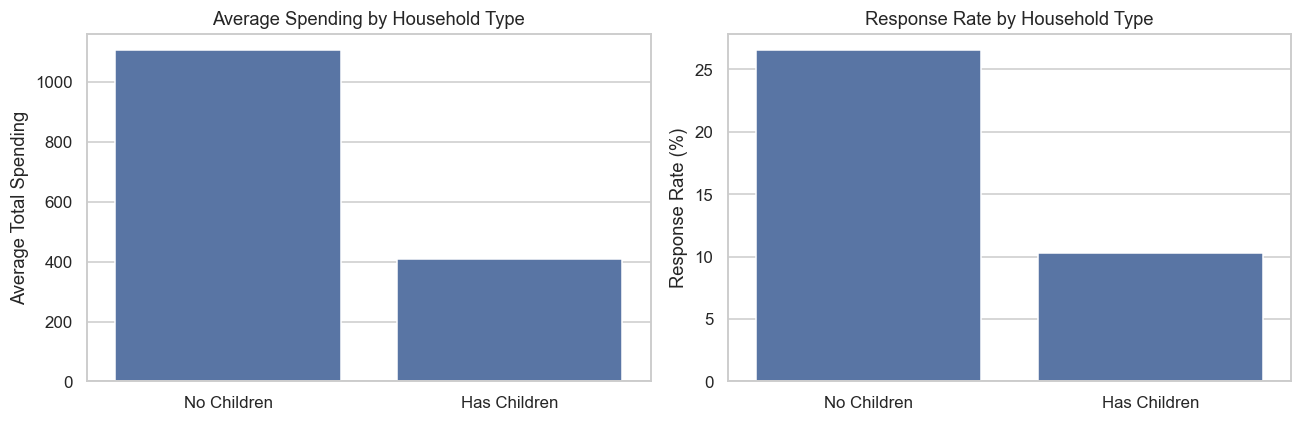

In [30]:
# Household composition is the clearest demographic pattern from the correlation analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

household_order = ["No Children", "Has Children"]

sns.barplot(
    data=household_summary,
    x="Household_Type",
    y="Avg_Total_Spending",
    order=household_order,
    ax=axes[0]
)
axes[0].set_title("Average Spending by Household Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average Total Spending")

sns.barplot(
    data=household_summary,
    x="Household_Type",
    y="Response_Rate_%",
    order=household_order,
    ax=axes[1]
)
axes[1].set_title("Response Rate by Household Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Response Rate (%)")

plt.tight_layout()
plt.show()

- Household composition is the clearest demographic pattern: customers without children spend on average **1,104.86**, compared with **407.03** for customers with children.
- The same group is also more responsive to campaigns, with a response rate of **26.53%** versus **10.31%**.
- Education shows some differences: `PhD`, `Graduation` and `Master` customers have higher average spending than `Basic` customers, but this pattern is less actionable than household composition.
- `Marital_Status` should be interpreted cautiously: some groups show higher spending or response, but differences are less stable and categories such as `Other` are very small.

### B.5 Purchase channel distribution

This section analyzes how customers purchase across web, catalog and store channels.  
The objective is to understand not only which channel generates the highest volume, but also which channel is associated with higher customer value and campaign responsiveness.

In [31]:
# Purchase channel columns represent where customers buy
channel_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]

channel_labels = {
    "NumWebPurchases": "Web",
    "NumCatalogPurchases": "Catalog",
    "NumStorePurchases": "Store"
}

# Total purchases show the overall commercial weight of each channel
channel_summary = (
    df_eda[channel_cols]
    .sum()
    .rename("Total_Purchases")
    .reset_index()
    .rename(columns={"index": "Channel"})
)

channel_summary["Channel"] = channel_summary["Channel"].map(channel_labels)
channel_summary["Purchase_Share_%"] = (
    channel_summary["Total_Purchases"] / channel_summary["Total_Purchases"].sum() * 100
).round(2)

display(channel_summary)

,Channel,Total_Purchases,Purchase_Share_%
0,Web,9143,32.58
1,Catalog,5956,21.23
2,Store,12962,46.19


In [32]:
# Preferred channel identifies the channel with the highest purchase count for each customer
def assign_preferred_channel(row):
    channel_values = row[channel_cols]
    
    if channel_values.sum() == 0:
        return "No Purchases"
    
    max_value = channel_values.max()
    top_channels = channel_values[channel_values == max_value].index.tolist()
    
    if len(top_channels) > 1:
        return "Mixed"
    
    return channel_labels[top_channels[0]]

df_eda["Preferred_Channel"] = df_eda.apply(assign_preferred_channel, axis=1)

preferred_channel_summary = (
    df_eda
    .groupby("Preferred_Channel")
    .agg(
        Customer_Count=("ID", "count"),
        Avg_Total_Spending=("Total_Spending", "mean"),
        Median_Total_Spending=("Total_Spending", "median"),
        Avg_Income=("Income", "mean"),
        Response_Rate=("Response", "mean")
    )
    .reset_index()
)

preferred_channel_summary["Customer_Share_%"] = (
    preferred_channel_summary["Customer_Count"] / len(df_eda) * 100
).round(2)

preferred_channel_summary["Response_Rate_%"] = (
    preferred_channel_summary["Response_Rate"] * 100
).round(2)

preferred_channel_summary = preferred_channel_summary.drop(columns="Response_Rate")

display(
    preferred_channel_summary
    .sort_values("Avg_Total_Spending", ascending=False)
    .round(2)
)

,Preferred_Channel,Customer_Count,Avg_Total_Spending,Median_Total_Spending,Avg_Income,Customer_Share_%,Response_Rate_%
0,Catalog,136,1340.65,1422.0,72889.55,6.08,34.56
4,Web,325,663.18,518.0,52204.79,14.53,24.31
3,Store,1477,555.17,252.0,50934.72,66.03,10.22
1,Mixed,293,468.14,215.0,47073.93,13.10,19.45
2,No Purchases,6,7.00,7.0,54160.67,0.27,0.00


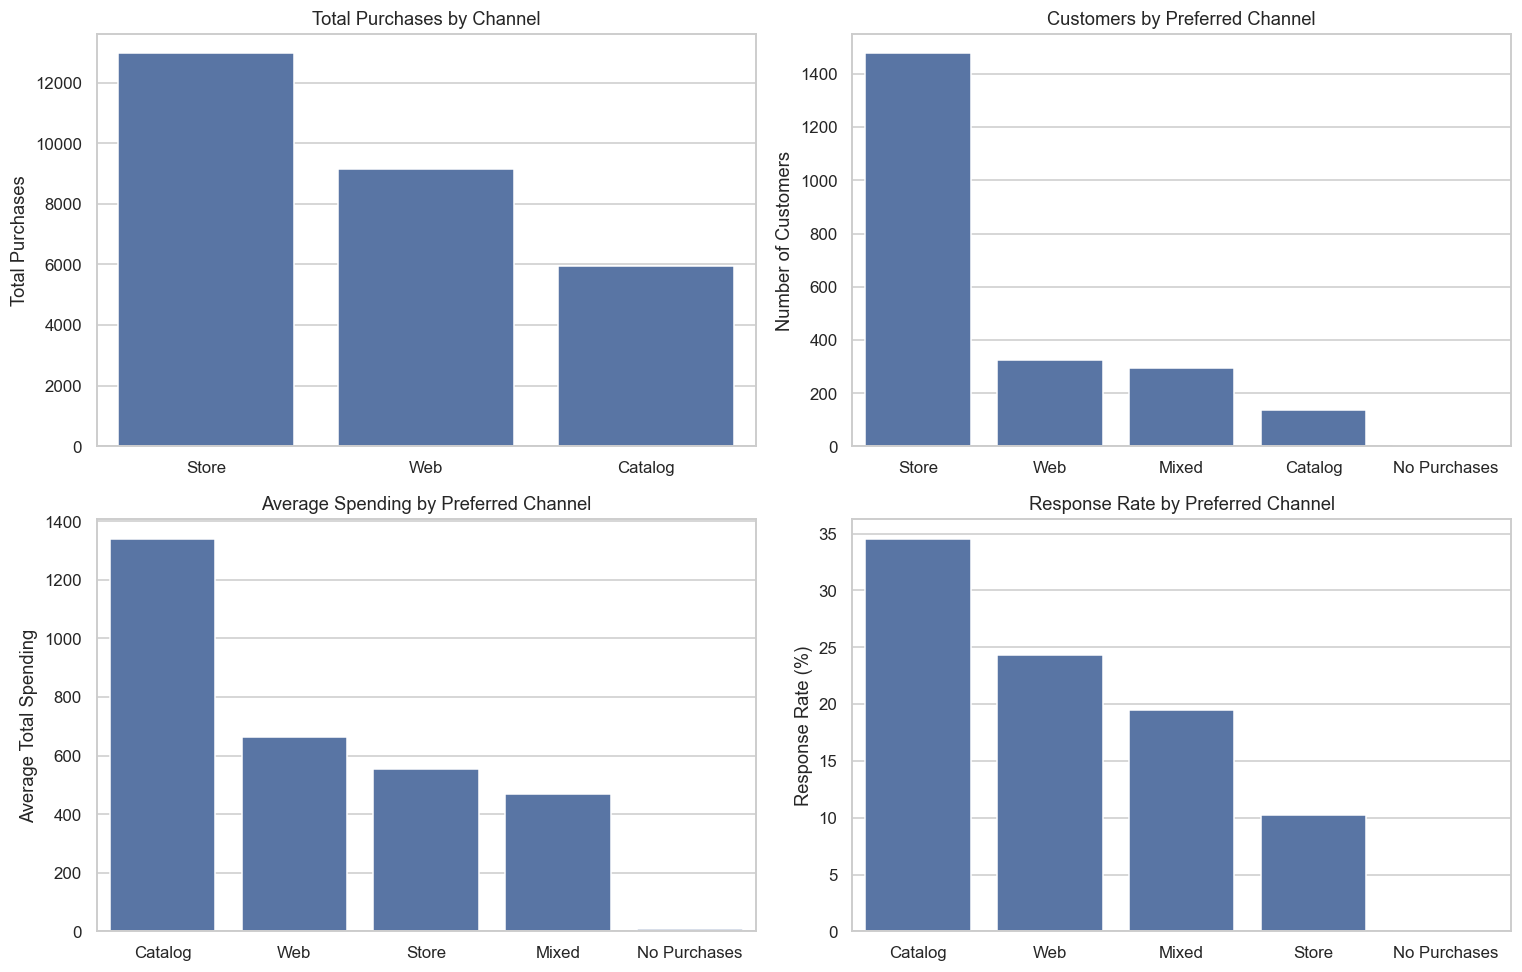

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

channel_order = (
    channel_summary
    .sort_values("Total_Purchases", ascending=False)["Channel"]
)

sns.barplot(
    data=channel_summary,
    x="Channel",
    y="Total_Purchases",
    order=channel_order,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Total Purchases by Channel")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Total Purchases")

preferred_order = (
    preferred_channel_summary
    .sort_values("Customer_Count", ascending=False)["Preferred_Channel"]
)

sns.barplot(
    data=preferred_channel_summary,
    x="Preferred_Channel",
    y="Customer_Count",
    order=preferred_order,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Customers by Preferred Channel")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Number of Customers")

value_order = (
    preferred_channel_summary
    .sort_values("Avg_Total_Spending", ascending=False)["Preferred_Channel"]
)

sns.barplot(
    data=preferred_channel_summary,
    x="Preferred_Channel",
    y="Avg_Total_Spending",
    order=value_order,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Average Spending by Preferred Channel")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Average Total Spending")

response_order = (
    preferred_channel_summary
    .sort_values("Response_Rate_%", ascending=False)["Preferred_Channel"]
)

sns.barplot(
    data=preferred_channel_summary,
    x="Preferred_Channel",
    y="Response_Rate_%",
    order=response_order,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Response Rate by Preferred Channel")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Response Rate (%)")

plt.tight_layout()
plt.show()

- Store is the dominant channel by total purchase volume, accounting for **46.19%** of all purchases, followed by Web (**32.58%**) and Catalog (**21.23%**).
- Most customers are store-oriented: **66.03%** have Store as their preferred channel, while only **6.08%** are catalog-preferring customers.
- Catalog is smaller in volume but much higher in value: catalog-preferring customers spend on average **1,340.65**, compared with **663.18** for Web and **555.17** for Store.
- Catalog-preferring customers also show the highest campaign response rate (**34.56%**), suggesting that Catalog is a high-value, high-responsiveness channel rather than an outdated channel.

### B.6 Product category spending

This section analyzes which product categories drive customer spending and how product preferences change across household types and preferred channels.

This is useful because the final campaign should not only target the right customers, but also promote the most relevant product categories for each segment.

In [34]:
# Product categories are analyzed to understand what drives customer value
product_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

product_labels = {
    "MntWines": "Wines",
    "MntFruits": "Fruits",
    "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish",
    "MntSweetProducts": "Sweets",
    "MntGoldProds": "Gold"
}

# Total spending by category shows the overall economic weight of each product family
product_summary = (
    df_eda[product_cols]
    .sum()
    .rename("Total_Spending")
    .reset_index()
    .rename(columns={"index": "Product_Category"})
)

product_summary["Product_Category"] = product_summary["Product_Category"].map(product_labels)

product_summary["Spending_Share_%"] = (
    product_summary["Total_Spending"] / product_summary["Total_Spending"].sum() * 100
).round(2)

product_summary = product_summary.sort_values("Spending_Share_%", ascending=False)

display(product_summary)

,Product_Category,Total_Spending,Spending_Share_%
0,Wines,680038,50.19
2,Meat,373393,27.56
5,Gold,98358,7.26
3,Fish,83939,6.19
4,Sweets,60553,4.47
1,Fruits,58767,4.34


In [35]:
# Household labels make the comparison easier to interpret
if "Household_Type" not in df_eda.columns:
    df_eda["Household_Type"] = df_eda["Has_Children"].map({
        0: "No Children",
        1: "Has Children"
    })

product_share_cols = [
    "Wine_Share", "Fruit_Share", "Meat_Share",
    "Fish_Share", "Sweet_Share", "Gold_Share"
]

product_share_labels = {
    "Wine_Share": "Wines",
    "Fruit_Share": "Fruits",
    "Meat_Share": "Meat",
    "Fish_Share": "Fish",
    "Sweet_Share": "Sweets",
    "Gold_Share": "Gold"
}

# Average product shares show relative preferences within each group
household_product_mix = (
    df_eda
    .groupby("Household_Type")[product_share_cols]
    .mean()
    .rename(columns=product_share_labels)
    .mul(100)
    .reset_index()
)

household_product_mix_long = household_product_mix.melt(
    id_vars="Household_Type",
    var_name="Product_Category",
    value_name="Average_Share_%"
)

display(household_product_mix.round(2))

,Household_Type,Wines,Fruits,Meat,Fish,Sweets,Gold
0,Has Children,48.53,4.56,22.60,6.51,4.65,13.15
1,No Children,39.16,5.94,30.87,8.72,6.15,9.15


In [36]:
# Channel-based product mix links product preferences to communication channel decisions
channel_product_mix = (
    df_eda
    .groupby("Preferred_Channel")[product_share_cols]
    .mean()
    .rename(columns=product_share_labels)
    .mul(100)
    .reset_index()
)

channel_product_mix_long = channel_product_mix.melt(
    id_vars="Preferred_Channel",
    var_name="Product_Category",
    value_name="Average_Share_%"
)

display(channel_product_mix.round(2))

,Preferred_Channel,Wines,Fruits,Meat,Fish,Sweets,Gold
0,Catalog,43.83,4.49,32.48,7.23,4.39,7.58
1,Mixed,45.64,5.00,24.30,6.14,4.79,14.12
2,No Purchases,30.51,13.06,21.16,11.57,8.80,14.91
3,Store,44.59,5.26,25.27,7.73,5.35,11.80
4,Web,53.01,3.55,21.02,5.25,4.32,12.87


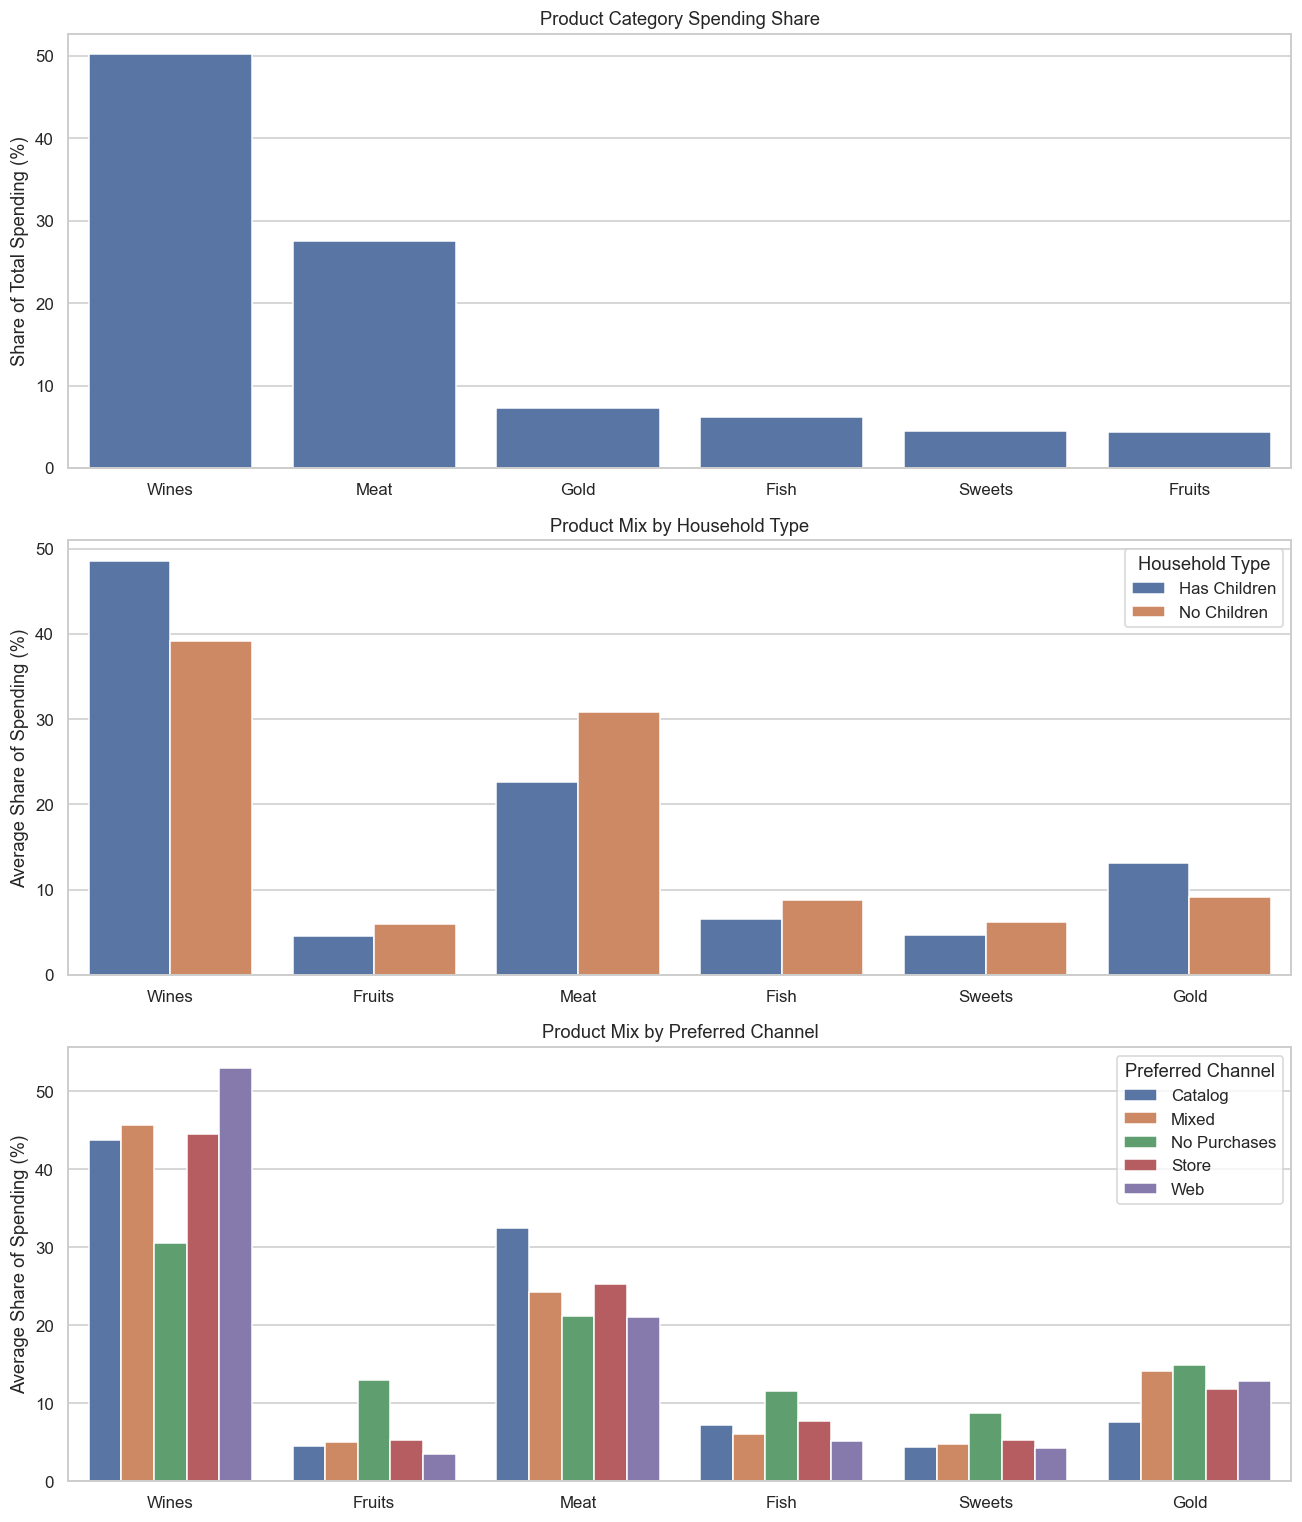

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

sns.barplot(
    data=product_summary,
    x="Product_Category",
    y="Spending_Share_%",
    ax=axes[0]
)
axes[0].set_title("Product Category Spending Share")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share of Total Spending (%)")

sns.barplot(
    data=household_product_mix_long,
    x="Product_Category",
    y="Average_Share_%",
    hue="Household_Type",
    ax=axes[1]
)
axes[1].set_title("Product Mix by Household Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average Share of Spending (%)")
axes[1].legend(title="Household Type")

sns.barplot(
    data=channel_product_mix_long,
    x="Product_Category",
    y="Average_Share_%",
    hue="Preferred_Channel",
    ax=axes[2]
)
axes[2].set_title("Product Mix by Preferred Channel")
axes[2].set_xlabel("")
axes[2].set_ylabel("Average Share of Spending (%)")
axes[2].legend(title="Preferred Channel")

plt.tight_layout()
plt.show()

- Wines dominate the product portfolio, accounting for **50.19%** of total spending, followed by Meat products at **27.56%**. These two categories are the main economic drivers of the basket.
- Product mix differs clearly by household type: customers without children allocate a higher share to Meat (**30.49%**) than customers with children (**22.06%**), while customers with children allocate a higher share to Wines (**48.55% vs 39.29%**) and Gold products (**13.15% vs 8.98%**).
- Catalog-preferring customers show a more premium-oriented mix, with the highest Meat share (**33.49%**) and relatively strong Wine share (**43.82%**), supporting the idea that catalog can work well for curated high-value offers.
- This product analysis helps shape the hidden trend campaign: the offer should not be generic, but built around a curated **Wine + Meat premium selection**, especially for high-value and catalog-responsive customers.

#### B.7 Candidate hidden trends

To avoid selecting a campaign target based on a single variable, three candidate trends are tested:

1. **Premium Lifestyle Segment:** customers without children in the household and with income above the 75th percentile.
2. **Catalog Premium Buyers:** customers whose preferred channel is Catalog.
3. **Digital Browsers:** customers with high web visits but low purchase activity.

The final hidden trend will be selected based on customer value, response rate and practical marketing actionability.

In [38]:
# Candidate 1: Premium Lifestyle Segment
# High income is defined using the 75th percentile of Income
income_threshold = df_eda["Income"].quantile(0.75)

df_eda["High_Income"] = (df_eda["Income"] > income_threshold).astype(int)

df_eda["Premium_Lifestyle_Segment"] = (
    (df_eda["High_Income"] == 1) &
    (df_eda["Has_Children"] == 0)
).astype(int)

# Candidate 2: Catalog Premium Buyers
# Catalog is tested because previous channel analysis showed high value and response
df_eda["Catalog_Premium_Buyer"] = (
    df_eda["Preferred_Channel"] == "Catalog"
).astype(int)

# Candidate 3: Digital Browsers
# High visits but low purchases may indicate browsing without conversion
web_visit_threshold = df_eda["NumWebVisitsMonth"].quantile(0.75)
purchase_threshold = df_eda["Total_Purchases"].quantile(0.25)

df_eda["Digital_Browser"] = (
    (df_eda["NumWebVisitsMonth"] >= web_visit_threshold) &
    (df_eda["Total_Purchases"] <= purchase_threshold)
).astype(int)

print(f"High-income threshold: {income_threshold:.2f}")
print(f"High web-visit threshold: {web_visit_threshold:.2f}")
print(f"Low purchase threshold: {purchase_threshold:.2f}")

High-income threshold: 68274.00
High web-visit threshold: 7.00
Low purchase threshold: 14.00


In [81]:
# This function compares each candidate segment with the rest of the customer base
def compare_candidate_segment(df, segment_col, segment_name):
    segment = df[df[segment_col] == 1]
    others = df[df[segment_col] == 0]
    
    segment_metrics = {
        "Candidate Trend": segment_name,
        "Customer_Count": len(segment),
        "Customer_Share_%": len(segment) / len(df) * 100,
        "Avg_Total_Spending": segment["Total_Spending"].mean(),
        "Median_Total_Spending": segment["Total_Spending"].median(),
        "Avg_Income": segment["Income"].mean(),
        "Avg_Total_Purchases": segment["Total_Purchases"].mean(),
        "Response_Rate_%": segment["Response"].mean() * 100,
        "Previous_Campaign_Acceptance_%": segment["Previous_Campaign_Accepted"].mean() * 100,
        "Others_Avg_Spending": others["Total_Spending"].mean(),
        "Others_Response_Rate_%": others["Response"].mean() * 100
    }
    
    segment_metrics["Spending_Uplift_vs_Others_%"] = (
        (segment_metrics["Avg_Total_Spending"] - segment_metrics["Others_Avg_Spending"]) /
        segment_metrics["Others_Avg_Spending"] * 100
    )
    
    segment_metrics["Response_Uplift_vs_Others_pp"] = (
        segment_metrics["Response_Rate_%"] - segment_metrics["Others_Response_Rate_%"]
    )
    
    return segment_metrics


candidate_results = pd.DataFrame([
    compare_candidate_segment(df_eda, "Premium_Lifestyle_Segment", "Premium Lifestyle Segment"),
    compare_candidate_segment(df_eda, "Catalog_Premium_Buyer", "Catalog Premium Buyers"),
    compare_candidate_segment(df_eda, "Digital_Browser", "Digital Browsers")
])

candidate_results = candidate_results.round(2)

display(candidate_results)

,Candidate Trend,Customer_Count,Customer_Share_%,Avg_Total_Spending,Median_Total_Spending,Avg_Income,Avg_Total_Purchases,Response_Rate_%,Previous_Campaign_Acceptance_%,Others_Avg_Spending,Others_Response_Rate_%,Spending_Uplift_vs_Others_%,Response_Uplift_vs_Others_pp
0,Premium Lifestyle Segment,388,17.34,1453.23,1440.0,80523.62,22.54,33.76,49.23,427.90,10.98,239.62,22.78
1,Catalog Premium Buyers,136,6.08,1340.65,1422.0,72889.55,23.30,34.56,39.71,558.17,13.66,140.19,20.90
2,Digital Browsers,262,11.71,39.15,36.5,30330.42,12.68,8.02,9.54,680.91,15.85,-94.25,-7.83


In [40]:
# A compact ranking helps compare value and responsiveness across candidate trends
hidden_trend_ranking = candidate_results[
    [
        "Candidate Trend",
        "Customer_Count",
        "Customer_Share_%",
        "Avg_Total_Spending",
        "Spending_Uplift_vs_Others_%",
        "Response_Rate_%",
        "Response_Uplift_vs_Others_pp",
        "Previous_Campaign_Acceptance_%"
    ]
].copy()

hidden_trend_ranking = hidden_trend_ranking.sort_values(
    ["Avg_Total_Spending", "Response_Rate_%"],
    ascending=False
)

display(hidden_trend_ranking)

,Candidate Trend,Customer_Count,Customer_Share_%,Avg_Total_Spending,Spending_Uplift_vs_Others_%,Response_Rate_%,Response_Uplift_vs_Others_pp,Previous_Campaign_Acceptance_%
0,Premium Lifestyle Segment,388,17.34,1453.23,239.62,33.76,22.78,49.23
1,Catalog Premium Buyers,136,6.08,1340.65,140.19,34.56,20.90,39.71
2,Digital Browsers,262,11.71,39.15,-94.25,8.02,-7.83,9.54


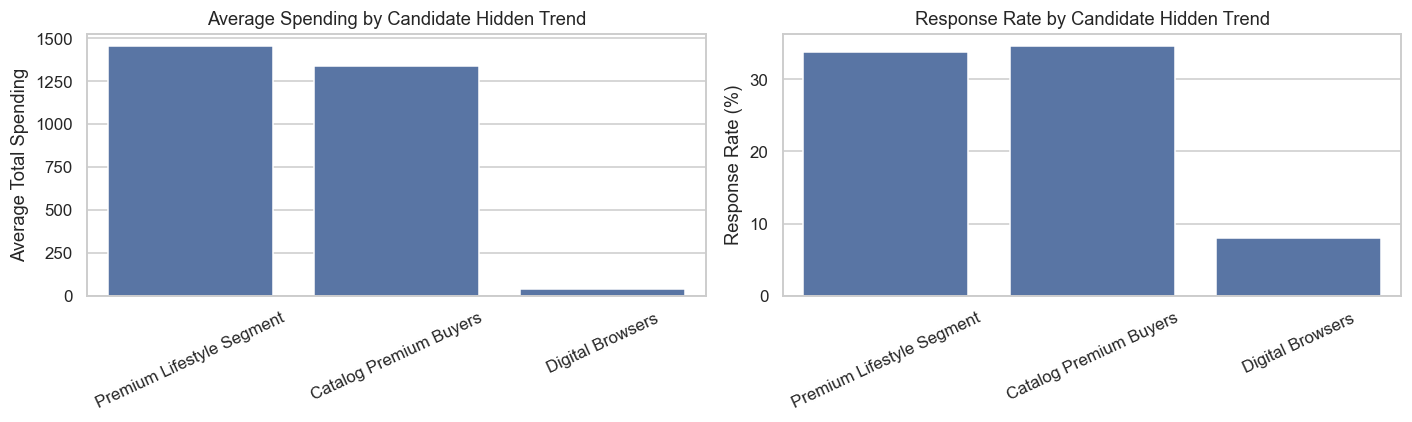

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(
    data=candidate_results,
    x="Candidate Trend",
    y="Avg_Total_Spending",
    ax=axes[0]
)
axes[0].set_title("Average Spending by Candidate Hidden Trend")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average Total Spending")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(
    data=candidate_results,
    x="Candidate Trend",
    y="Response_Rate_%",
    ax=axes[1]
)
axes[1].set_title("Response Rate by Candidate Hidden Trend")
axes[1].set_xlabel("")
axes[1].set_ylabel("Response Rate (%)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

**Candidate hidden trends — interpretation**

- The `Premium Lifestyle Segment` is the strongest candidate overall: it combines the highest average spending with a strong campaign response rate.
- `Catalog Premium Buyers` are also valuable and highly responsive, but they represent a much smaller group; this makes Catalog more useful as a communication channel than as the main target definition.
- `Digital Browsers` show the opposite pattern: despite high website activity, they have very low spending and a weaker response rate, suggesting browsing friction rather than premium potential.
- Based on value, responsiveness and marketing actionability, the selected hidden trend is the `Premium Lifestyle Segment`.

The next step validates this selected segment in more detail by comparing it with the rest of the customer base in terms of spending, response, product mix and preferred channel.

In [48]:
df_eda["Premium_Lifestyle_Label"] = df_eda["Premium_Lifestyle_Segment"].map({
    0: "Others",
    1: "Premium Lifestyle"
})

premium_summary = (
    df_eda
    .groupby("Premium_Lifestyle_Label")
    .agg(
        Customer_Count=("ID", "count"),
        Avg_Total_Spending=("Total_Spending", "mean"),
        Median_Total_Spending=("Total_Spending", "median"),
        Avg_Income=("Income", "mean"),
        Avg_Total_Purchases=("Total_Purchases", "mean"),
        Response_Rate=("Response", "mean"),
        Previous_Campaign_Acceptance=("Previous_Campaign_Accepted", "mean")
    )
    .reset_index()
)

premium_summary["Customer_Share_%"] = (
    premium_summary["Customer_Count"] / len(df_eda) * 100
)

premium_summary["Response_Rate_%"] = premium_summary["Response_Rate"] * 100
premium_summary["Previous_Campaign_Acceptance_%"] = (
    premium_summary["Previous_Campaign_Acceptance"] * 100
)

premium_summary = premium_summary.drop(
    columns=["Response_Rate", "Previous_Campaign_Acceptance"]
)

premium_summary = premium_summary[
    [
        "Premium_Lifestyle_Label",
        "Customer_Count",
        "Customer_Share_%",
        "Avg_Total_Spending",
        "Median_Total_Spending",
        "Avg_Income",
        "Avg_Total_Purchases",
        "Response_Rate_%",
        "Previous_Campaign_Acceptance_%"
    ]
]

display(premium_summary.round(2))

,Premium_Lifestyle_Label,Customer_Count,Customer_Share_%,Avg_Total_Spending,Median_Total_Spending,Avg_Income,Avg_Total_Purchases,Response_Rate_%,Previous_Campaign_Acceptance_%
0,Others,1849,82.66,427.90,222.0,45962.45,19.70,10.98,14.66
1,Premium Lifestyle,388,17.34,1453.23,1440.0,80523.62,22.54,33.76,49.23


The `Premium Lifestyle Segment` represents only **17.34%** of customers, but it spends much more than others (**1,453.23 vs 427.90**) and shows stronger campaign responsiveness (**33.76% vs 10.98%**), making it a high-value target for premium communication.

In [43]:
# Channel distribution helps decide how to reach this segment
premium_channel_distribution = (
    pd.crosstab(
        df_eda["Preferred_Channel"],
        df_eda["Premium_Lifestyle_Label"],
        normalize="columns"
    ) * 100
).round(2)

display(premium_channel_distribution)

Premium_Lifestyle_Label,Others,Premium Lifestyle
Preferred_Channel,,
Catalog,3.19,19.85
Mixed,14.60,5.93
No Purchases,0.22,0.52
Store,65.77,67.27
Web,16.22,6.44


The Premium Lifestyle Segment is still mainly store-oriented (**67.27%**), but Catalog is much more relevant for this group than for others (**19.85% vs 3.19%**). This suggests that premium catalog-style communication can be especially effective for this target.

In [ ]:
# Product mix shows which categories should anchor the campaign
product_share_cols = [
    "Wine_Share", "Fruit_Share", "Meat_Share",
    "Fish_Share", "Sweet_Share", "Gold_Share"
]

product_mix_premium = (
    df_eda
    .groupby("Premium_Lifestyle_Label")[product_share_cols]
    .mean()
    .mul(100)
    .reset_index()
)

product_mix_premium = product_mix_premium.rename(columns={
    "Wine_Share": "Wines",
    "Fruit_Share": "Fruits",
    "Meat_Share": "Meat",
    "Fish_Share": "Fish",
    "Sweet_Share": "Sweets",
    "Gold_Share": "Gold"
})

product_mix_premium_long = product_mix_premium.melt(
    id_vars="Premium_Lifestyle_Label",
    var_name="Product_Category",
    value_name="Average_Share_%"
)

display(product_mix_premium.round(2))

,Premium_Lifestyle_Label,Wines,Fruits,Meat,Fish,Sweets,Gold
0,Others,46.49,5.01,22.90,7.20,5.05,13.36
1,Premium Lifestyle,42.87,4.67,34.76,6.88,5.23,5.58


The Premium Lifestyle Segment still allocates the largest share to Wines (**42.87%**), but its distinctive product signal is Meat: **34.76%** of spending versus **22.90%** among others. This supports a premium campaign built around a curated **Wine + Meat selection**, rather than a generic wine-only promotion.

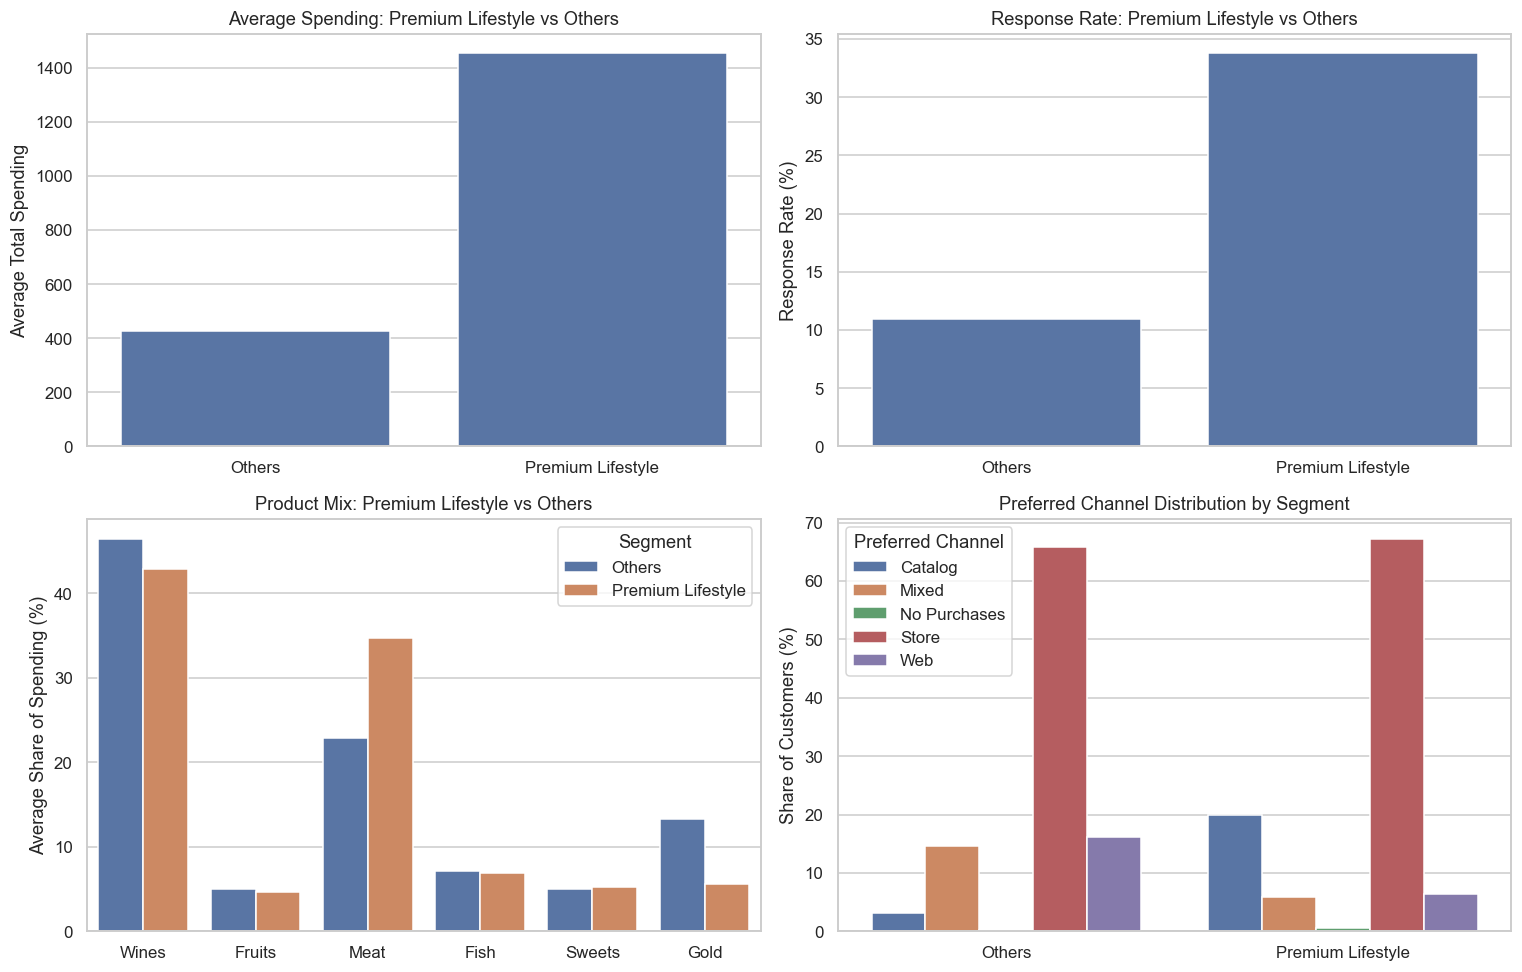

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

segment_order = ["Others", "Premium Lifestyle"]

sns.barplot(
    data=premium_summary,
    x="Premium_Lifestyle_Label",
    y="Avg_Total_Spending",
    order=segment_order,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Average Spending: Premium Lifestyle vs Others")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Average Total Spending")

sns.barplot(
    data=premium_summary,
    x="Premium_Lifestyle_Label",
    y="Response_Rate_%",
    order=segment_order,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Response Rate: Premium Lifestyle vs Others")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Response Rate (%)")

sns.barplot(
    data=product_mix_premium_long,
    x="Product_Category",
    y="Average_Share_%",
    hue="Premium_Lifestyle_Label",
    hue_order=segment_order,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Product Mix: Premium Lifestyle vs Others")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Average Share of Spending (%)")
axes[1, 0].legend(title="Segment")

premium_channel_plot = (
    premium_channel_distribution
    .reset_index()
    .melt(
        id_vars="Preferred_Channel",
        var_name="Premium_Lifestyle_Label",
        value_name="Customer_Share_%"
    )
)

sns.barplot(
    data=premium_channel_plot,
    x="Premium_Lifestyle_Label",
    y="Customer_Share_%",
    hue="Preferred_Channel",
    order=segment_order,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Preferred Channel Distribution by Segment")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Share of Customers (%)")
axes[1, 1].legend(title="Preferred Channel")

plt.tight_layout()
plt.show()

The visual comparison confirms that the `Premium Lifestyle Segment` is both more valuable and more responsive than the rest of the customer base. Its average spending is more than three times higher, and its response rate is also substantially stronger.

The product mix shows that Wines remain important for both groups, but the distinctive signal of the Premium Lifestyle Segment is the much higher Meat share. This supports a curated **Wine + Meat premium offer**, rather than a generic wine promotion.

From a channel perspective, Store remains the dominant channel, but Catalog is clearly more relevant for Premium Lifestyle customers than for others. This suggests that the campaign should combine **premium email communication with catalog-style curated offers**, using a more exclusive and personalized tone.

In [46]:
# Previous campaign acceptance is used as an activation layer within the premium segment
premium_activation = (
    df_eda[df_eda["Premium_Lifestyle_Segment"] == 1]
    .groupby("Previous_Campaign_Accepted")
    .agg(
        Customer_Count=("ID", "count"),
        Avg_Total_Spending=("Total_Spending", "mean"),
        Response_Rate=("Response", "mean"),
        Avg_Total_Purchases=("Total_Purchases", "mean")
    )
    .reset_index()
)

premium_activation["Previous_Campaign_Accepted"] = premium_activation[
    "Previous_Campaign_Accepted"
].map({
    0: "No Previous Acceptance",
    1: "Previous Acceptance"
})

premium_activation["Response_Rate_%"] = premium_activation["Response_Rate"] * 100
premium_activation = premium_activation.drop(columns="Response_Rate")

display(premium_activation.round(2))

,Previous_Campaign_Accepted,Customer_Count,Avg_Total_Spending,Avg_Total_Purchases,Response_Rate_%
0,No Previous Acceptance,197,1299.07,21.89,17.26
1,Previous Acceptance,191,1612.24,23.20,50.79


Within the `Premium Lifestyle Segment`, previous campaign acceptance clearly identifies the most responsive customers. Customers with previous acceptance show a much higher response rate (**50.79%**) than those without previous acceptance (**17.26%**), while also spending more on average (**1,612.24 vs 1,299.07**).

This suggests that previous campaign responders should be prioritized in the first activation wave, while non-responders can receive a softer premium awareness message.

In [47]:
# Final campaign idea derived from the hidden trend analysis
hidden_trend_selection = pd.DataFrame({
    "Selected Hidden Trend": ["Premium Lifestyle Segment"],
    "Definition": ["Customers without children in the household and Income above the 75th percentile"],
    "Why It Matters": ["Small but high-value and highly responsive group"],
    "Recommended Campaign": ["Curated Wine + Meat premium offer with early access or loyalty benefits"],
    "Recommended Activation Layer": ["Prioritize customers with previous campaign acceptance"]
})

display(hidden_trend_selection)

,Selected Hidden Trend,Definition,Why It Matters,Recommended Campaign,Recommended Activation Layer
0,Premium Lifestyle Segment,Customers without children in the household an...,Small but high-value and highly responsive group,Curated Wine + Meat premium offer with early a...,Prioritize customers with previous campaign ac...


**Hidden trend selection — final interpretation**

The selected hidden trend is the `Premium Lifestyle Segment`: customers without children in the household and with income above the 75th percentile.

This segment is not only high-income, but also combines higher spending, stronger response rate and a more premium product mix. The most actionable campaign opportunity is therefore a curated **Wine + Meat premium offer**, communicated through personalized email and catalog-style content.

Previous campaign acceptance should be used to prioritize the first wave of the campaign, because already-engaged customers within this segment show the highest likelihood of responding again.

---------------

## Task C — RFM Calculation & Heuristic Segmentation

This task segments customers using the RFM framework: Recency, Frequency and Monetary value.

The goal is to transform purchase behavior into interpretable customer segments that can support marketing prioritization and later be compared with cluster analysis.

In [49]:
# Task C starts from the EDA dataframe enriched with spending and purchase features
df_rfm = df_eda.copy()

print(f"RFM dataframe: {df_rfm.shape[0]:,} rows × {df_rfm.shape[1]} columns")

RFM dataframe: 2,237 rows × 51 columns


### C.1 Build the RFM variables

RFM segmentation summarizes customer value through three purchase-based dimensions: how recently customers bought, how often they buy, and how much they spend.

Here, `Recency` is taken from the original dataset, `Frequency` is based on total purchases, and `Monetary` is based on total spending.

In [50]:
# Recency measures how recently the customer purchased; lower values are better
df_rfm["RFM_Recency"] = df_rfm["Recency"]

# Frequency is based on actual purchase channels, not discount usage
df_rfm["RFM_Frequency"] = df_rfm["Total_Purchases"]

# Monetary captures total customer spending across product categories
df_rfm["RFM_Monetary"] = df_rfm["Total_Spending"]

rfm_cols = ["RFM_Recency", "RFM_Frequency", "RFM_Monetary"]

rfm_quality_check = pd.DataFrame({
    "Missing Values": df_rfm[rfm_cols].isna().sum(),
    "Zero Values": (df_rfm[rfm_cols] == 0).sum()
})

display(rfm_quality_check)

rfm_summary = df_rfm[rfm_cols].describe().T.round(2)

display(rfm_summary)

,Missing Values,Zero Values
RFM_Recency,0,28
RFM_Frequency,0,2
RFM_Monetary,0,0


,count,mean,std,min,25%,50%,75%,max
RFM_Recency,2237.0,49.10,28.96,0.0,24.0,49.0,74.0,99.0
RFM_Frequency,2237.0,20.19,7.29,0.0,14.0,19.0,25.0,46.0
RFM_Monetary,2237.0,605.74,601.84,5.0,69.0,396.0,1045.0,2525.0


- No missing values are present in the RFM variables, so all **2,237 customers** can be included in the segmentation.
- `RFM_Recency` ranges from **0 to 99 days**, where lower values indicate more recent customers.
- `RFM_Frequency` has an average of **20.19 purchases**, with only **2 zero-purchase customers**.
- `RFM_Monetary` has a mean of **605.74** and a median of **396.00**, suggesting that spending is not evenly distributed across customers.

### C.2 Inspect RFM distributions

Before assigning quintile scores, we inspect the distribution of the three RFM variables.  
This helps verify whether customers differ enough in recency, purchase frequency and spending to justify segmentation.

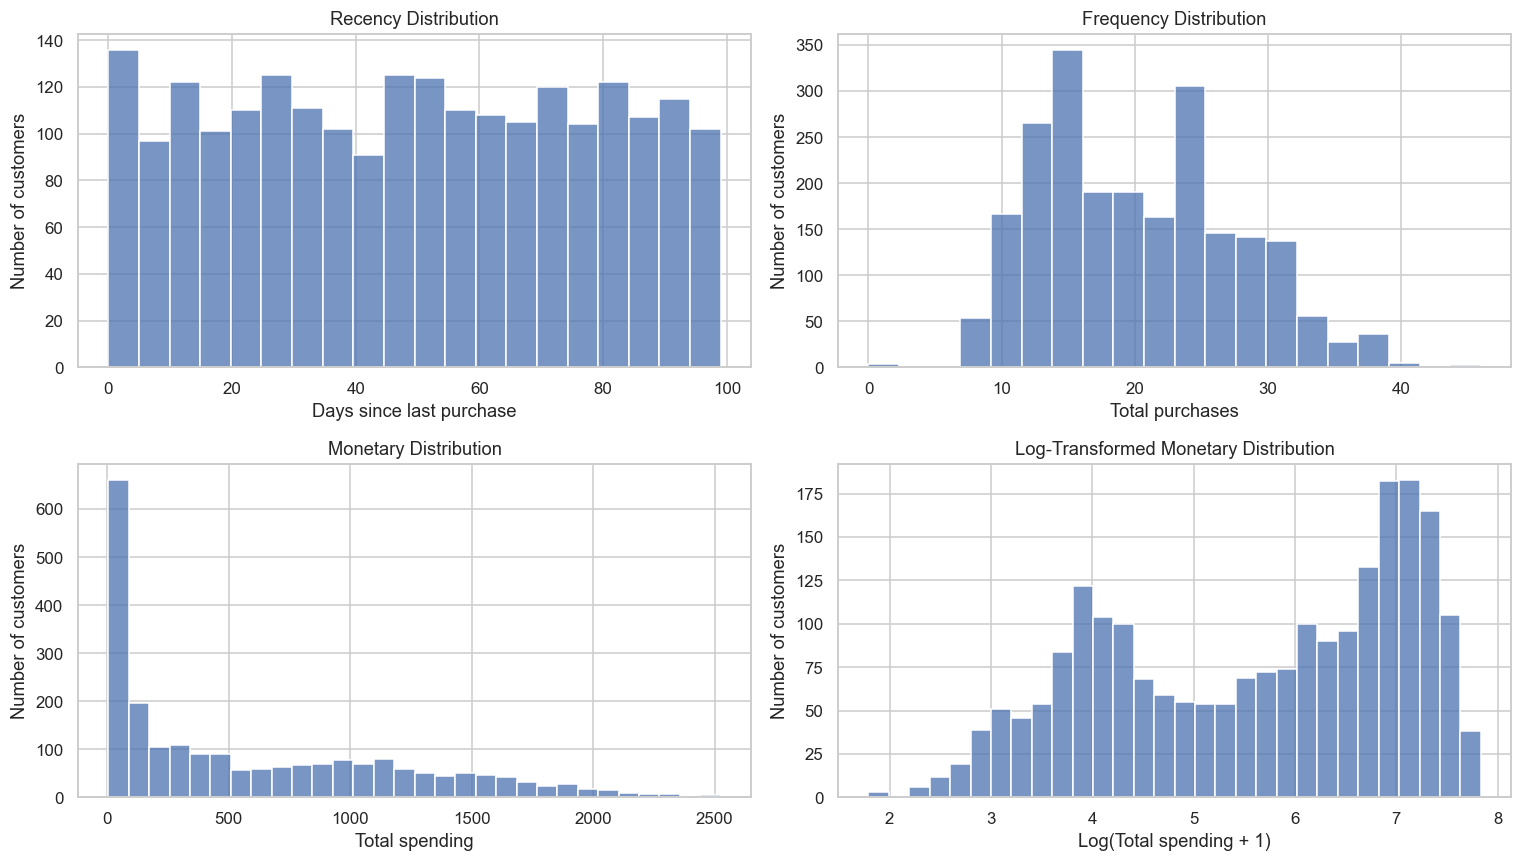

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Recency distribution shows how recently customers purchased
sns.histplot(df_rfm["RFM_Recency"], bins=20, ax=axes[0, 0])
axes[0, 0].set_title("Recency Distribution")
axes[0, 0].set_xlabel("Days since last purchase")
axes[0, 0].set_ylabel("Number of customers")

# Frequency distribution captures purchase activity differences
sns.histplot(df_rfm["RFM_Frequency"], bins=20, ax=axes[0, 1])
axes[0, 1].set_title("Frequency Distribution")
axes[0, 1].set_xlabel("Total purchases")
axes[0, 1].set_ylabel("Number of customers")

# Monetary distribution shows customer value concentration
sns.histplot(df_rfm["RFM_Monetary"], bins=30, ax=axes[1, 0])
axes[1, 0].set_title("Monetary Distribution")
axes[1, 0].set_xlabel("Total spending")
axes[1, 0].set_ylabel("Number of customers")

# Log transformation makes the skewed monetary distribution easier to read
sns.histplot(np.log1p(df_rfm["RFM_Monetary"]), bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Log-Transformed Monetary Distribution")
axes[1, 1].set_xlabel("Log(Total spending + 1)")
axes[1, 1].set_ylabel("Number of customers")

plt.tight_layout()
plt.show()

- `Recency` is spread across the full observed range, confirming that the dataset includes both recent and less recent customers.
- `Frequency` is concentrated around medium purchase levels, with fewer very high-frequency customers.
- `Monetary` is strongly right-skewed: many customers spend little, while a smaller group generates much higher value.

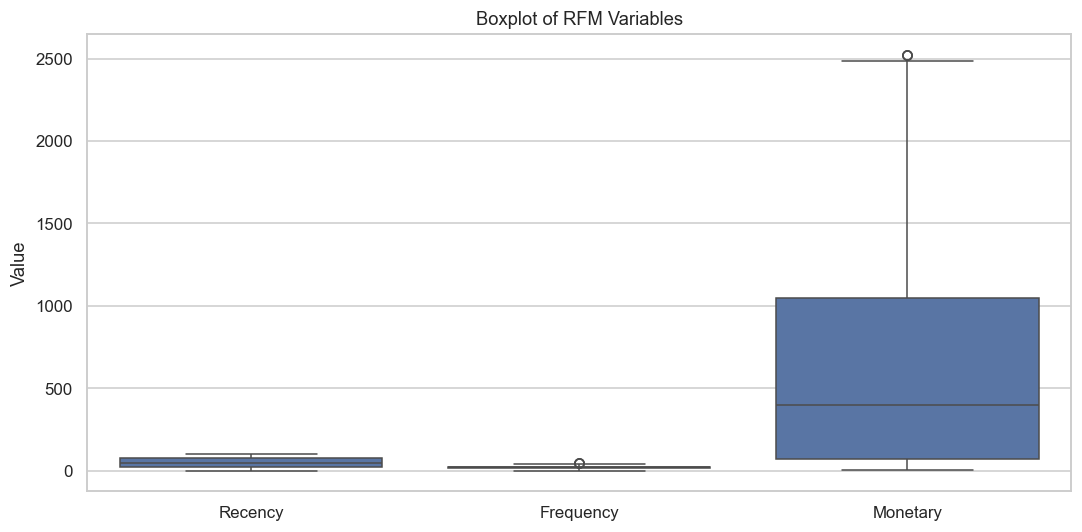

In [52]:
rfm_long = df_rfm[["RFM_Recency", "RFM_Frequency", "RFM_Monetary"]].rename(columns={
    "RFM_Recency": "Recency",
    "RFM_Frequency": "Frequency",
    "RFM_Monetary": "Monetary"
}).melt(var_name="RFM Variable", value_name="Value")

plt.figure(figsize=(10, 5))
sns.boxplot(data=rfm_long, x="RFM Variable", y="Value")
plt.title("Boxplot of RFM Variables")
plt.xlabel("")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

The boxplot confirms that the three RFM variables have very different ranges. `Monetary` shows the widest dispersion and visible high-value observations, while `Recency` and `Frequency` are more compressed. This supports the use of quintile scoring, because it standardizes the three dimensions before combining them into RFM segments.

These distributions confirm that customers differ meaningfully in recency, frequency and monetary value. To compare the three dimensions fairly, the next step transforms each variable into quintile-based RFM scores.

### C.3 Assign quintile-based RFM scores

The three RFM variables are transformed into scores from **1 to 5** using quintiles.  
For `Recency`, the score is reversed because lower recency means the customer purchased more recently. For `Frequency` and `Monetary`, higher values receive higher scores.

In [53]:
# Ranking avoids qcut errors when many customers have the same value
df_rfm["R_Score"] = pd.qcut(
    df_rfm["RFM_Recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Higher purchase frequency indicates stronger customer activity
df_rfm["F_Score"] = pd.qcut(
    df_rfm["RFM_Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Higher monetary value indicates stronger customer value
df_rfm["M_Score"] = pd.qcut(
    df_rfm["RFM_Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# The combined RFM code keeps the three dimensions visible
df_rfm["RFM_Score"] = (
    df_rfm["R_Score"].astype(str) +
    df_rfm["F_Score"].astype(str) +
    df_rfm["M_Score"].astype(str)
)

# The total score is useful for quick ranking, but not enough for final segmentation
df_rfm["RFM_Total_Score"] = (
    df_rfm["R_Score"] +
    df_rfm["F_Score"] +
    df_rfm["M_Score"]
)

score_cols = [
    "ID",
    "RFM_Recency",
    "RFM_Frequency",
    "RFM_Monetary",
    "R_Score",
    "F_Score",
    "M_Score",
    "RFM_Score",
    "RFM_Total_Score"
]

display(df_rfm[score_cols].head())

score_distribution = pd.DataFrame({
    "R_Score": df_rfm["R_Score"].value_counts().sort_index(),
    "F_Score": df_rfm["F_Score"].value_counts().sort_index(),
    "M_Score": df_rfm["M_Score"].value_counts().sort_index()
})

display(score_distribution)

display(df_rfm["RFM_Total_Score"].describe().round(2))

,ID,RFM_Recency,RFM_Frequency,RFM_Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total_Score
0,5524,58,32,1617,3,5,5,355,13
1,2174,38,11,27,4,1,1,411,6
2,4141,26,25,776,4,4,4,444,12
3,6182,26,14,53,4,2,1,421,7
4,5324,94,24,422,1,4,3,143,8


,R_Score,F_Score,M_Score
1,448,448,448
2,447,447,447
3,447,447,447
4,447,447,447
5,448,448,448


count    2237.00
mean        9.00
std         2.98
min         3.00
25%         7.00
50%         9.00
75%        11.00
max        15.00
Name: RFM_Total_Score, dtype: float64

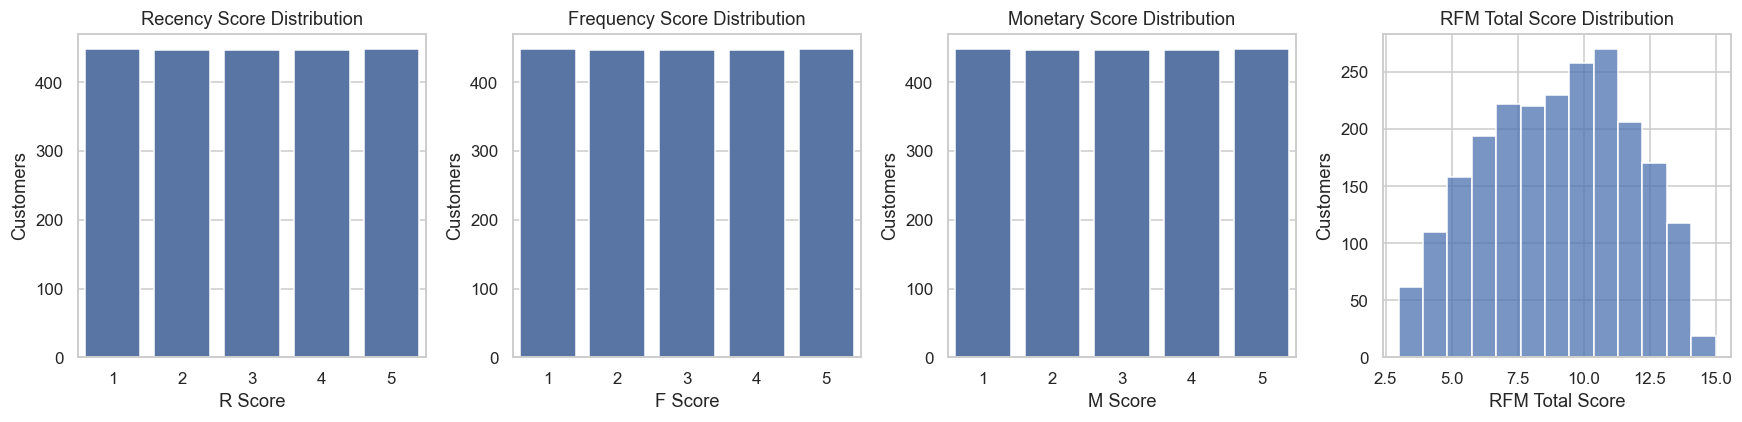

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sns.countplot(data=df_rfm, x="R_Score", order=[1, 2, 3, 4, 5], ax=axes[0])
axes[0].set_title("Recency Score Distribution")
axes[0].set_xlabel("R Score")
axes[0].set_ylabel("Customers")

sns.countplot(data=df_rfm, x="F_Score", order=[1, 2, 3, 4, 5], ax=axes[1])
axes[1].set_title("Frequency Score Distribution")
axes[1].set_xlabel("F Score")
axes[1].set_ylabel("Customers")

sns.countplot(data=df_rfm, x="M_Score", order=[1, 2, 3, 4, 5], ax=axes[2])
axes[2].set_title("Monetary Score Distribution")
axes[2].set_xlabel("M Score")
axes[2].set_ylabel("Customers")

sns.histplot(df_rfm["RFM_Total_Score"], bins=13, ax=axes[3])
axes[3].set_title("RFM Total Score Distribution")
axes[3].set_xlabel("RFM Total Score")
axes[3].set_ylabel("Customers")

plt.tight_layout()
plt.show()

- Quintile scoring successfully creates balanced groups: each `R_Score`, `F_Score` and `M_Score` level contains around **447–448 customers**.
- `R_Score` is correctly reversed, so customers with more recent purchases receive higher scores.
- `F_Score` and `M_Score` increase with purchase frequency and total spending, making higher scores more valuable from a marketing perspective.
- `RFM_Total_Score` ranges from **3 to 15** and is concentrated around the middle values, suggesting that most customers have mixed RFM profiles rather than extreme behavior.

### C.4 Define heuristic RFM segments

After assigning RFM scores, customers are grouped into interpretable segments.  
The goal is not only to rank customers, but to create actionable categories for marketing prioritization.

In [55]:
# Segment rules are ordered from most specific/high-priority to more general groups
def assign_rfm_segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"
    
    elif row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Loyal Big Spenders"
    
    elif row["R_Score"] <= 2 and row["M_Score"] >= 4:
        return "High Value At Risk"
    
    elif row["R_Score"] >= 4 and row["F_Score"] <= 3 and row["M_Score"] <= 3:
        return "Promising Recent Customers"
    
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2 and row["M_Score"] <= 2:
        return "Hibernating Low Value"
    
    else:
        return "Regular Customers"


df_rfm["RFM_Segment"] = df_rfm.apply(assign_rfm_segment, axis=1)

segment_distribution = (
    df_rfm["RFM_Segment"]
    .value_counts()
    .rename_axis("RFM_Segment")
    .reset_index(name="Customer_Count")
)

segment_distribution["Customer_Share_%"] = (
    segment_distribution["Customer_Count"] / len(df_rfm) * 100
).round(2)

display(segment_distribution)

,RFM_Segment,Customer_Count,Customer_Share_%
0,Regular Customers,721,32.23
1,Promising Recent Customers,453,20.25
2,Loyal Big Spenders,393,17.57
3,Hibernating Low Value,306,13.68
4,Champions,257,11.49
5,High Value At Risk,107,4.78


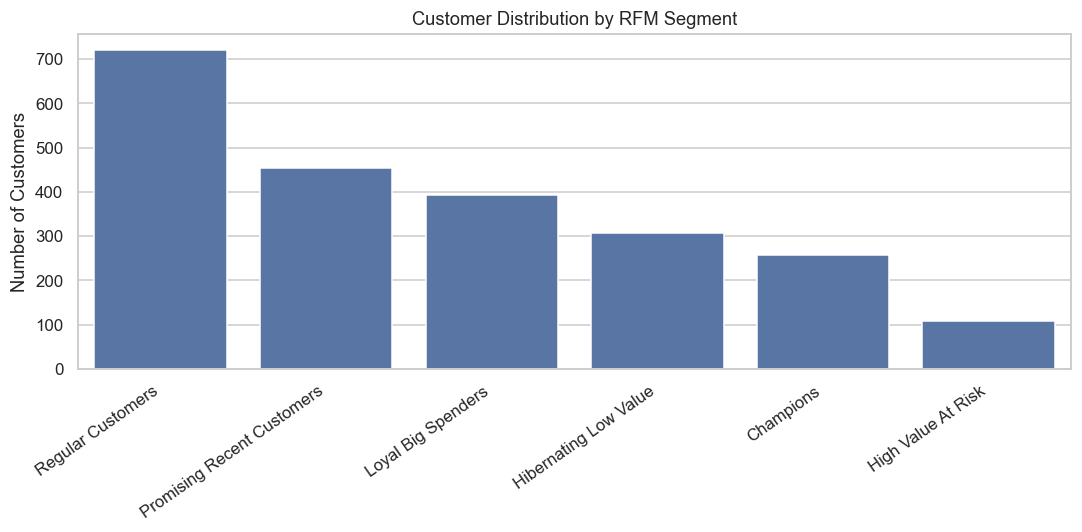

In [56]:
plt.figure(figsize=(10, 5))

segment_order = (
    segment_distribution
    .sort_values("Customer_Count", ascending=False)["RFM_Segment"]
)

sns.barplot(
    data=segment_distribution,
    x="RFM_Segment",
    y="Customer_Count",
    order=segment_order
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("")
plt.ylabel("Number of Customers")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**RFM segment definition — interpretation**

- The heuristic rules create **6 actionable RFM segments**:
- `Regular Customers` form the largest segment, representing the broad middle of the customer base with mixed RFM profiles.
- `Promising Recent Customers` have purchased recently but still need to be developed in terms of frequency and monetary value.
- `Champions` are the strongest customers overall: they are recent, frequent and high-spending, so they should be protected with loyalty benefits and premium communication.
- `Loyal Big Spenders` are highly valuable because they buy frequently and spend a lot, even if they are not always the most recent customers.
- `High Value At Risk` is smaller but strategically important because these customers have strong monetary value but weaker recency, making them suitable for reactivation campaigns.
- `Hibernating Low Value` customers show weak RFM performance and should receive only low-cost automated reactivation rather than expensive personalized campaigns.

### C.5 Segment profiling and visualization

After defining the RFM segments, we profile them to understand their size, value, revenue contribution and campaign responsiveness.

This step helps identify which segments should be prioritized for retention, reactivation or low-cost nurturing.

In [57]:
# A helper function extracts the most frequent channel within each segment
def most_common_value(series):
    mode_values = series.mode()
    if len(mode_values) == 0:
        return "N/A"
    return mode_values.iloc[0]


# Segment profiling combines RFM behavior with marketing-relevant variables
segment_summary = (
    df_rfm
    .groupby("RFM_Segment")
    .agg(
        Customer_Count=("ID", "count"),
        Avg_Recency=("RFM_Recency", "mean"),
        Median_Recency=("RFM_Recency", "median"),
        Avg_Frequency=("RFM_Frequency", "mean"),
        Median_Frequency=("RFM_Frequency", "median"),
        Avg_Monetary=("RFM_Monetary", "mean"),
        Median_Monetary=("RFM_Monetary", "median"),
        Total_Revenue=("RFM_Monetary", "sum"),
        Avg_Income=("Income", "mean"),
        Response_Rate=("Response", "mean"),
        Most_Common_Preferred_Channel=("Preferred_Channel", most_common_value)
    )
    .reset_index()
)

segment_summary["Customer_Share_%"] = (
    segment_summary["Customer_Count"] / len(df_rfm) * 100
)

segment_summary["Revenue_Share_%"] = (
    segment_summary["Total_Revenue"] / df_rfm["RFM_Monetary"].sum() * 100
)

segment_summary["Response_Rate_%"] = segment_summary["Response_Rate"] * 100
segment_summary = segment_summary.drop(columns="Response_Rate")

# Add Premium Lifestyle share if the variable exists from Task B
if "Premium_Lifestyle_Segment" in df_rfm.columns:
    premium_share = (
        df_rfm
        .groupby("RFM_Segment")["Premium_Lifestyle_Segment"]
        .mean()
        .mul(100)
        .reset_index(name="Premium_Lifestyle_Share_%")
    )
    segment_summary = segment_summary.merge(premium_share, on="RFM_Segment", how="left")

# Add no-children share if available
if "Has_Children" in df_rfm.columns:
    no_children_share = (
        df_rfm
        .groupby("RFM_Segment")["Has_Children"]
        .apply(lambda x: (x == 0).mean() * 100)
        .reset_index(name="No_Children_Share_%")
    )
    segment_summary = segment_summary.merge(no_children_share, on="RFM_Segment", how="left")

segment_summary = segment_summary.sort_values("Revenue_Share_%", ascending=False)

display(segment_summary.round(2))

,RFM_Segment,Customer_Count,Avg_Recency,Median_Recency,Avg_Frequency,Median_Frequency,Avg_Monetary,Median_Monetary,Total_Revenue,Avg_Income,Most_Common_Preferred_Channel,Customer_Share_%,Revenue_Share_%,Response_Rate_%,Premium_Lifestyle_Share_%,No_Children_Share_%
3,Loyal Big Spenders,393,69.54,70.0,28.39,28.0,1235.93,1168.0,485721,68621.45,Store,17.57,35.85,17.05,30.03,40.20
5,Regular Customers,721,50.03,50.0,19.70,20.0,484.99,353.0,349679,49461.49,Store,32.23,25.81,14.84,15.53,25.52
0,Champions,257,18.98,20.0,28.54,28.0,1184.66,1099.0,304458,69697.92,Store,11.49,22.47,29.57,31.52,41.25
2,High Value At Risk,107,78.01,78.0,18.57,19.0,1310.51,1198.0,140225,76646.00,Store,4.78,10.35,15.89,70.09,85.05
4,Promising Recent Customers,453,19.35,19.0,14.49,14.0,122.64,68.0,55554,37079.72,Store,20.25,4.10,13.47,0.00,13.91
1,Hibernating Low Value,306,79.92,80.0,12.81,13.0,63.43,54.0,19411,34925.41,Store,13.68,1.43,1.96,0.65,11.44


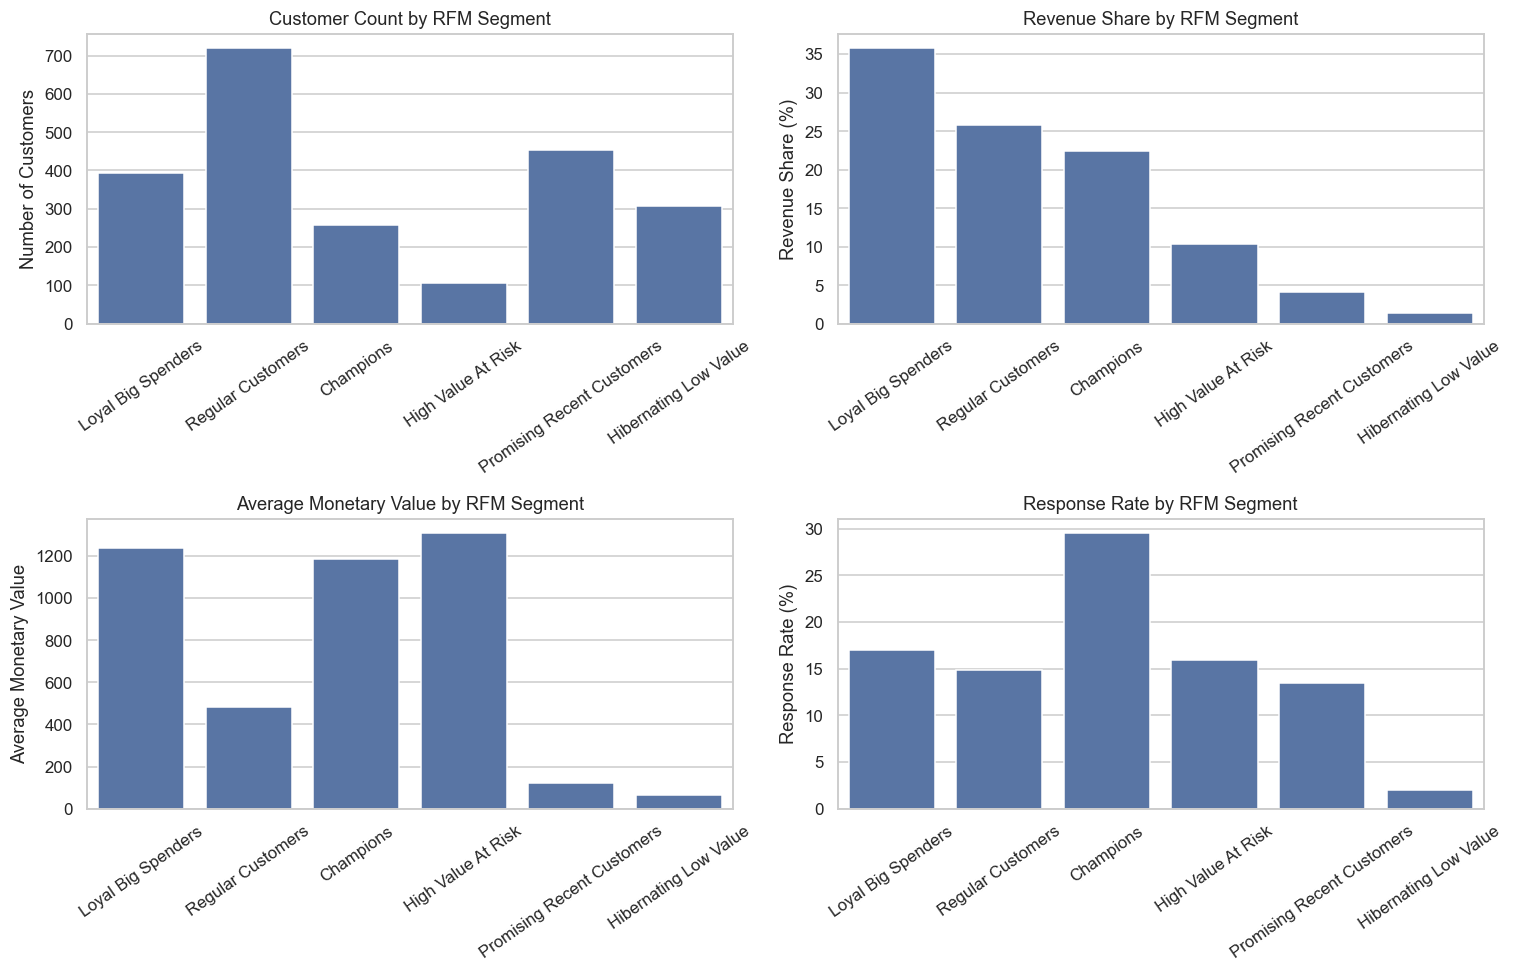

In [58]:
# Revenue-based ordering highlights the most economically relevant segments
segment_order = segment_summary["RFM_Segment"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.barplot(
    data=segment_summary,
    x="RFM_Segment",
    y="Customer_Count",
    order=segment_order,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Customer Count by RFM Segment")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Number of Customers")
axes[0, 0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=segment_summary,
    x="RFM_Segment",
    y="Revenue_Share_%",
    order=segment_order,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Revenue Share by RFM Segment")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Revenue Share (%)")
axes[0, 1].tick_params(axis="x", rotation=35)

sns.barplot(
    data=segment_summary,
    x="RFM_Segment",
    y="Avg_Monetary",
    order=segment_order,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Average Monetary Value by RFM Segment")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Average Monetary Value")
axes[1, 0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=segment_summary,
    x="RFM_Segment",
    y="Response_Rate_%",
    order=segment_order,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Response Rate by RFM Segment")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Response Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

- `Loyal Big Spenders` are the most important revenue segment: they represent around **17.6%** of customers but generate about **35.8%** of total revenue.
- `Champions` are smaller, around **11.5%** of customers, but generate about **22.5%** of revenue and show the highest campaign response rate, making them ideal for retention and premium loyalty actions.
- Together, `Champions` and `Loyal Big Spenders` represent about **29%** of the customer base but generate around **58%** of total revenue. This confirms a strong Pareto-style concentration of customer value.
- `High Value At Risk` customers are a small segment, around **4.8%** of customers, but they have the highest average monetary value. Their high recency suggests they should be targeted with reactivation before their value is lost.
- `Promising Recent Customers` are recent but low-spending, so they should be developed through onboarding or second-purchase campaigns rather than premium offers.
- `Hibernating Low Value` customers have low monetary value and the weakest response rate, so they should receive only low-cost automated reactivation.

In [59]:
# Pareto-style check: how much revenue is generated by the top RFM segments?
top_segments = ["Champions", "Loyal Big Spenders"]

top_segment_summary = segment_summary[
    segment_summary["RFM_Segment"].isin(top_segments)
]

top_customer_share = top_segment_summary["Customer_Share_%"].sum()
top_revenue_share = top_segment_summary["Revenue_Share_%"].sum()

print(f"Champions + Loyal Big Spenders customer share: {top_customer_share:.2f}%")
print(f"Champions + Loyal Big Spenders revenue share: {top_revenue_share:.2f}%")

Champions + Loyal Big Spenders customer share: 29.06%
Champions + Loyal Big Spenders revenue share: 58.31%


**Pareto-style revenue concentration**

`Champions` and `Loyal Big Spenders` represent only **29.06%** of customers, but they generate **58.31%** of total revenue.

This confirms that customer value is highly concentrated: a minority of customers accounts for the majority of business value. These two segments should therefore be prioritized for retention, loyalty benefits, premium offers and personalized communication.

---------------

## TASK D — Unsupervised Learning: Cluster Analysis

This task applies K-Means clustering to identify data-driven customer groups. Unlike RFM, which ranks customers only by recency, frequency and monetary value, clustering can capture broader behavioral patterns such as channel preference, household structure, income level, web engagement and past campaign behavior.

### D.1 Feature selection for clustering

The clustering model should use variables that describe customer behavior and profile, but not variables that directly encode campaign outcomes or previously created segment labels.

For this reason, `Response`, RFM scores and RFM segment labels are excluded from the clustering input and will only be used later for interpretation and comparison.

In [60]:
# Task D starts from the RFM dataframe, which already includes engineered variables from previous tasks
df_cluster = df_rfm.copy()

# Clustering features describe customer profile, value, channel behavior and product preferences
cluster_features = [
    # Customer profile
    "Age",
    "Income",
    "Children",
    "Has_Children",
    "Customer_Tenure_Days",
    
    # Purchase behavior
    "Recency",
    "Total_Purchases",
    "Total_Spending",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    
    # Channel preference
    "Web_Share",
    "Catalog_Share",
    "Store_Share",
    
    # Product mix
    "Wine_Share",
    "Fruit_Share",
    "Meat_Share",
    "Fish_Share",
    "Sweet_Share",
    "Gold_Share"
]

# Keep only available features to avoid errors if a column name changed
cluster_features = [col for col in cluster_features if col in df_cluster.columns]

X_cluster = df_cluster[cluster_features].copy()

print(f"Number of clustering features selected: {len(cluster_features)}")
print("Selected clustering features:")
print(cluster_features)

feature_audit = pd.DataFrame({
    "Feature": cluster_features,
    "Missing Values": X_cluster.isna().sum().values,
    "Data Type": X_cluster.dtypes.astype(str).values
})

display(feature_audit)
display(X_cluster.describe().T.round(2))

Number of clustering features selected: 19
Selected clustering features:
['Age', 'Income', 'Children', 'Has_Children', 'Customer_Tenure_Days', 'Recency', 'Total_Purchases', 'Total_Spending', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Web_Share', 'Catalog_Share', 'Store_Share', 'Wine_Share', 'Fruit_Share', 'Meat_Share', 'Fish_Share', 'Sweet_Share', 'Gold_Share']


,Feature,Missing Values,Data Type
0,Age,0,int64
1,Income,0,float64
2,Children,0,int64
3,Has_Children,0,int64
4,Customer_Tenure_Days,0,int64
5,Recency,0,int64
6,Total_Purchases,0,int64
7,Total_Spending,0,int64
8,NumDealsPurchases,0,int64
9,NumWebVisitsMonth,0,int64


,count,mean,std,min,25%,50%,75%,max
Age,2237.0,45.10,11.70,18.0,37.00,44.00,55.00,74.00
Income,2237.0,51956.97,21408.03,1730.0,35523.00,51479.00,68274.00,162397.00
Children,2237.0,0.95,0.75,0.0,0.00,1.00,1.00,3.00
Has_Children,2237.0,0.72,0.45,0.0,0.00,1.00,1.00,1.00
Customer_Tenure_Days,2237.0,353.79,202.14,0.0,181.00,356.00,529.00,699.00
Recency,2237.0,49.10,28.96,0.0,24.00,49.00,74.00,99.00
Total_Purchases,2237.0,20.19,7.29,0.0,14.00,19.00,25.00,46.00
Total_Spending,2237.0,605.74,601.84,5.0,69.00,396.00,1045.00,2525.00
NumDealsPurchases,2237.0,2.33,1.93,0.0,1.00,2.00,3.00,15.00
NumWebVisitsMonth,2237.0,5.32,2.43,0.0,3.00,6.00,7.00,20.00


- The clustering input includes **19 features** covering customer profile, purchase value, channel behavior, product mix and digital engagement.
- No missing values are present in the selected features, so all **2,237 customers** can be included in the K-Means analysis.
- `Response`, RFM scores and `RFM_Segment` are intentionally excluded because they represent campaign outcomes or previous segmentation labels, not independent clustering inputs.
- The selected variables have very different scales, especially `Income`, `Total_Spending`, `Total_Purchases` and share variables; therefore, scaling will be required before applying K-Means.
- This feature set allows clustering to capture broader customer personas beyond RFM, including household composition, channel preference and product-category orientation.

### D.2 Prepare features for K-Means

K-Means is distance-based, so variables with larger numerical ranges could dominate the clustering result if left untreated.

To avoid this, strongly skewed positive variables are log-transformed, and all selected features are then standardized so that each variable contributes on a comparable scale.

In [61]:
from sklearn.preprocessing import StandardScaler

# Work on a prepared copy to preserve the original variables for interpretation
X_prepared = X_cluster.copy()

# These variables are positive and highly skewed, so log transformation reduces their dominance
skewed_features = [
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Customer_Tenure_Days"
]

# Keep only available columns to avoid errors if a feature name changes
skewed_features = [col for col in skewed_features if col in X_prepared.columns]

for col in skewed_features:
    X_prepared[col] = np.log1p(X_prepared[col])

# Standardization is required because K-Means uses distance between observations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prepared)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X_prepared.columns,
    index=X_prepared.index
)

scaling_check = pd.DataFrame({
    "Feature": X_scaled_df.columns,
    "Scaled Mean": X_scaled_df.mean().round(3).values,
    "Scaled Std": X_scaled_df.std().round(3).values,
    "Min": X_scaled_df.min().round(2).values,
    "Max": X_scaled_df.max().round(2).values
})

display(scaling_check)

,Feature,Scaled Mean,Scaled Std,Min,Max
0,Age,0.0,1.0,-2.32,2.47
1,Income,0.0,1.0,-6.59,2.49
2,Children,0.0,1.0,-1.26,2.73
3,Has_Children,-0.0,1.0,-1.58,0.63
4,Customer_Tenure_Days,0.0,1.0,-5.81,1.01
5,Recency,0.0,1.0,-1.70,1.72
6,Total_Purchases,0.0,1.0,-8.13,2.34
7,Total_Spending,-0.0,1.0,-2.61,1.51
8,NumDealsPurchases,0.0,1.0,-2.29,3.59
9,NumWebVisitsMonth,-0.0,1.0,-3.77,2.78


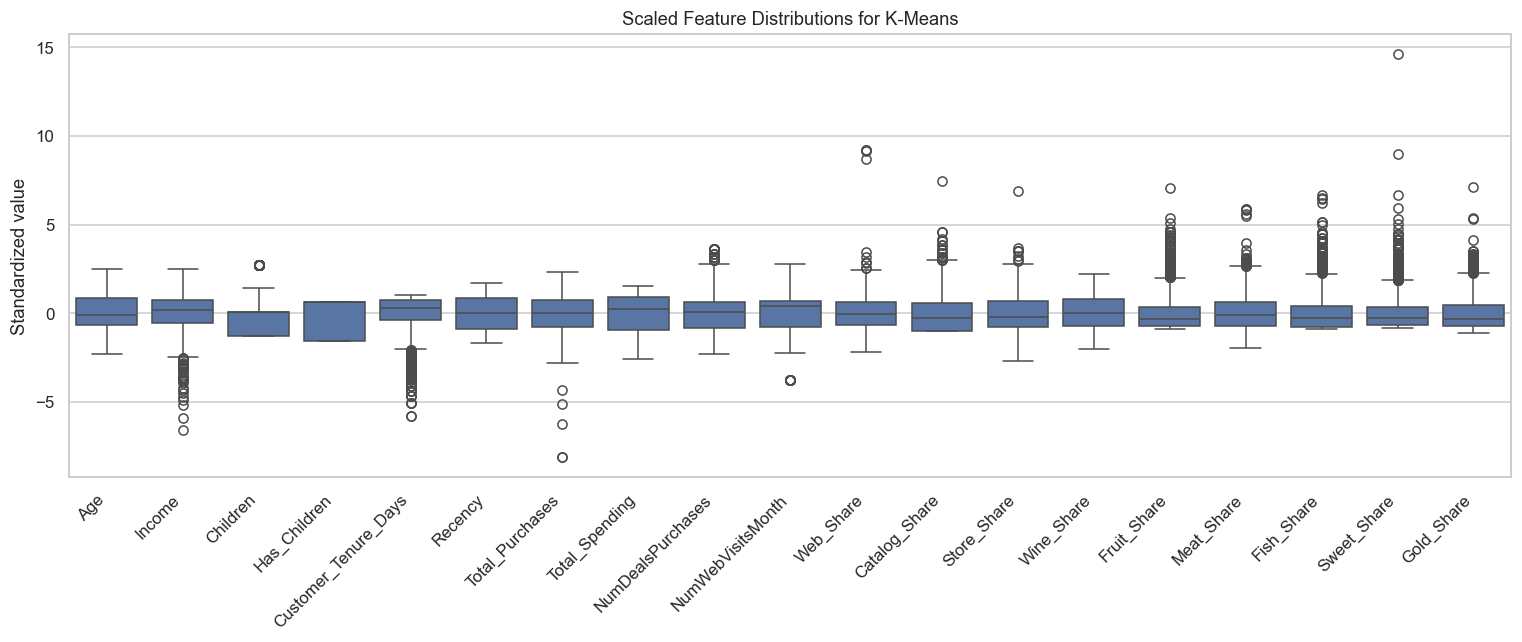

In [62]:
# The boxplot checks whether the features are now on comparable standardized scales
scaled_long = X_scaled_df.melt(
    var_name="Feature",
    value_name="Scaled Value"
)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=scaled_long,
    x="Feature",
    y="Scaled Value"
)
plt.title("Scaled Feature Distributions for K-Means")
plt.xlabel("")
plt.ylabel("Standardized value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- After standardization, all clustering features are centered around comparable scales, which is necessary because K-Means is distance-based.
- Log transformation reduces the dominance of highly skewed variables such as `Income`, `Total_Spending`, `Total_Purchases`, web visits and deal purchases.
- Some variables still show outliers after scaling, especially product-share variables, but these values represent meaningful customer preferences rather than data errors.
- The prepared feature matrix is now suitable for K-Means, because no single variable should dominate the clustering only because of its original scale.

### D.3 Choose the optimal number of clusters

Before fitting the final K-Means model, we compare different values of `k` using the Elbow Method and the Silhouette Score.

The goal is to choose a number of clusters that is statistically reasonable but also interpretable from a marketing perspective.

In [63]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test a range of possible cluster numbers
k_range = range(2, 9)

inertia_values = []
silhouette_values = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, cluster_labels))

cluster_metrics = pd.DataFrame({
    "k": list(k_range),
    "Inertia": inertia_values,
    "Silhouette_Score": silhouette_values
})

display(cluster_metrics.round(4))

,k,Inertia,Silhouette_Score
0,2,34220.0697,0.1900
1,3,28892.1064,0.1922
2,4,26329.4704,0.1704
3,5,25168.3531,0.1466
4,6,24263.2335,0.1317
5,7,23488.9321,0.1173
6,8,22877.6392,0.1180


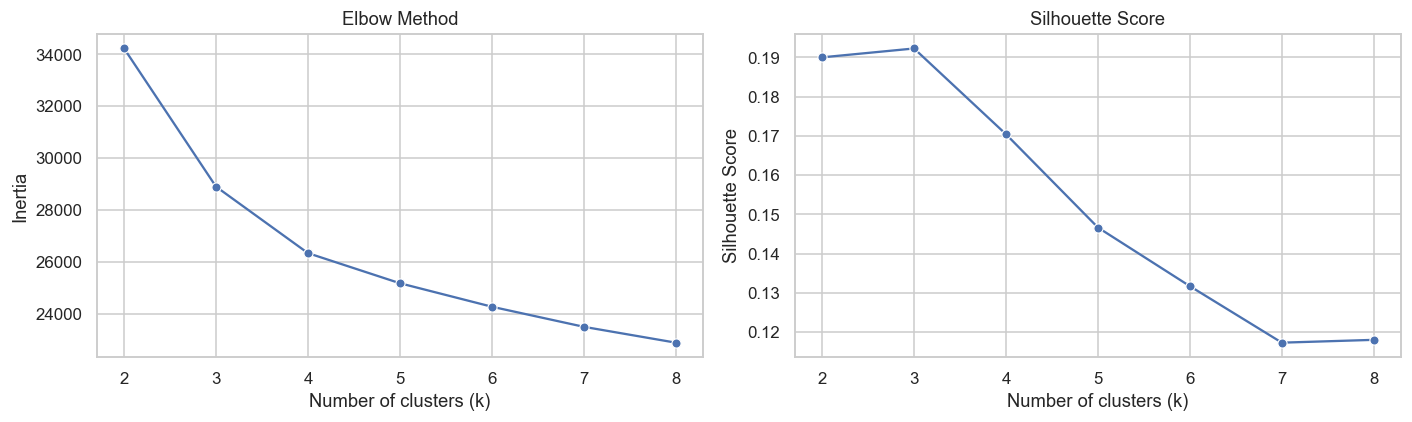

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(
    data=cluster_metrics,
    x="k",
    y="Inertia",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

sns.lineplot(
    data=cluster_metrics,
    x="k",
    y="Silhouette_Score",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [65]:
# k = 4 is selected as a balance between statistical support and business interpretability
selected_k = 4

print(f"Selected number of clusters: k = {selected_k}")

Selected number of clusters: k = 4


- The Elbow Method shows a strong reduction in inertia from **k = 2** to **k = 4**, after which the improvement becomes more gradual.
- The Silhouette Score is highest around **k = 3**, suggesting that a 3-cluster solution is statistically compact.
- However, **k = 4** is selected because it provides a better balance between statistical quality and business interpretability: it avoids an overly broad segmentation and allows more differentiated customer personas.
- This choice is appropriate for marketing analysis because the objective is not only mathematical compactness, but also creating clusters that can support distinct communication strategies.

### D.4 Fit the K-Means model

After selecting `k = 4`, we fit the final K-Means model on the standardized feature matrix.

The model assigns each customer to one cluster based on similarity across customer profile, purchase behavior, product mix, channel preference and digital engagement.

In [66]:
# Fit the final K-Means model using the selected number of clusters
kmeans_final = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

# Cluster labels are assigned to each customer
df_cluster["Cluster"] = kmeans_final.fit_predict(X_scaled)

cluster_distribution = (
    df_cluster["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Customer_Count")
)

cluster_distribution["Customer_Share_%"] = (
    cluster_distribution["Customer_Count"] / len(df_cluster) * 100
).round(2)

display(cluster_distribution)

,Cluster,Customer_Count,Customer_Share_%
0,0,539,24.09
1,1,533,23.83
2,2,764,34.15
3,3,401,17.93


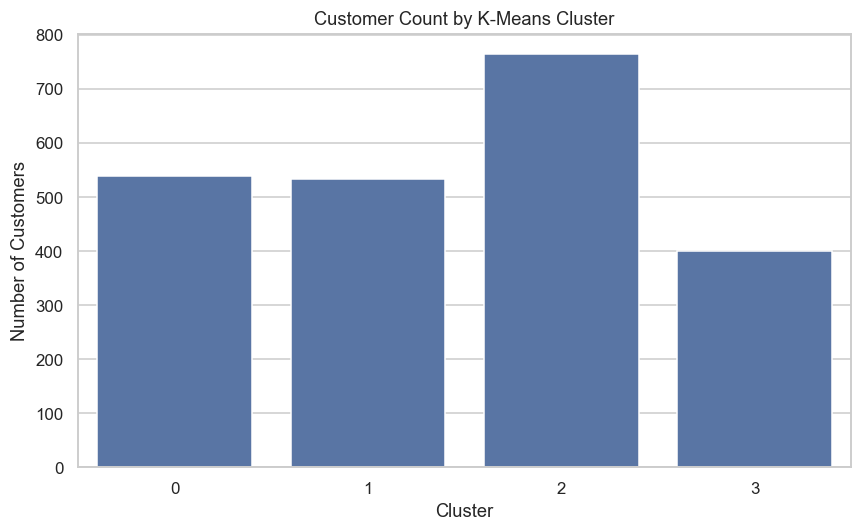

In [67]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_distribution,
    x="Cluster",
    y="Customer_Count"
)

plt.title("Customer Count by K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

- The final K-Means model assigns all customers to **4 clusters**, as selected in the previous step.
- The clusters are not perfectly equal in size: Cluster **2** is the largest group, while Cluster **3** is the smallest.
- This is expected because K-Means does not force equal-sized groups; it groups customers based on similarity across the selected features.
- At this stage, cluster numbers are only technical labels. Their business meaning will be defined in the next step by profiling each cluster’s spending, channel behavior, product mix and customer characteristics.

### D.5 Profile K-Means clusters

After assigning customers to clusters, we profile each group using business-relevant variables.

This step gives meaning to the numerical cluster labels by comparing size, spending, income, household composition, channel behavior, product mix and campaign responsiveness.

In [68]:
# Helper function to extract the most common value in each cluster
def most_common_value(series):
    mode_values = series.mode()
    if len(mode_values) == 0:
        return "N/A"
    return mode_values.iloc[0]


# Main cluster profile combines customer value, behavior and demographic characteristics
cluster_profile = (
    df_cluster
    .groupby("Cluster")
    .agg(
        Customer_Count=("ID", "count"),
        Avg_Total_Spending=("Total_Spending", "mean"),
        Median_Total_Spending=("Total_Spending", "median"),
        Total_Revenue=("Total_Spending", "sum"),
        Avg_Total_Purchases=("Total_Purchases", "mean"),
        Avg_Income=("Income", "mean"),
        Avg_Age=("Age", "mean"),
        Avg_Children=("Children", "mean"),
        Avg_Recency=("Recency", "mean"),
        Avg_Deals_Purchases=("NumDealsPurchases", "mean"),
        Avg_Web_Visits=("NumWebVisitsMonth", "mean"),
        Response_Rate=("Response", "mean"),
        Most_Common_Preferred_Channel=("Preferred_Channel", most_common_value)
    )
    .reset_index()
)

cluster_profile["Customer_Share_%"] = (
    cluster_profile["Customer_Count"] / len(df_cluster) * 100
)

cluster_profile["Revenue_Share_%"] = (
    cluster_profile["Total_Revenue"] / df_cluster["Total_Spending"].sum() * 100
)

cluster_profile["Response_Rate_%"] = cluster_profile["Response_Rate"] * 100
cluster_profile = cluster_profile.drop(columns="Response_Rate")

# Add Premium Lifestyle share if available from Task B
if "Premium_Lifestyle_Segment" in df_cluster.columns:
    premium_cluster_share = (
        df_cluster
        .groupby("Cluster")["Premium_Lifestyle_Segment"]
        .mean()
        .mul(100)
        .reset_index(name="Premium_Lifestyle_Share_%")
    )
    cluster_profile = cluster_profile.merge(premium_cluster_share, on="Cluster", how="left")

cluster_profile = cluster_profile.sort_values("Revenue_Share_%", ascending=False)

display(cluster_profile.round(2))

,Cluster,Customer_Count,Avg_Total_Spending,Median_Total_Spending,Total_Revenue,Avg_Total_Purchases,Avg_Income,Avg_Age,Avg_Children,Avg_Recency,Avg_Deals_Purchases,Avg_Web_Visits,Most_Common_Preferred_Channel,Customer_Share_%,Revenue_Share_%,Response_Rate_%,Premium_Lifestyle_Share_%
1,1,533,1311.43,1315.0,698990,22.38,74968.31,45.62,0.07,49.46,1.11,2.51,Store,23.83,51.58,27.95,72.05
2,2,764,754.95,682.5,576783,26.37,58427.76,48.48,1.21,48.78,3.66,5.82,Store,34.15,42.57,12.96,0.26
0,0,539,74.19,55.0,39989,13.67,38270.36,45.01,1.56,49.68,2.00,6.37,Store,24.09,2.95,7.98,0.00
3,3,401,97.97,60.0,39286,14.26,27439.15,38.09,0.80,48.48,1.85,6.69,Store,17.93,2.90,10.72,0.50


In [69]:
# Channel shares show how each cluster tends to buy
channel_cols = ["Web_Share", "Catalog_Share", "Store_Share"]

cluster_channel_profile = (
    df_cluster
    .groupby("Cluster")[channel_cols]
    .mean()
    .mul(100)
    .reset_index()
)

cluster_channel_profile = cluster_channel_profile.rename(columns={
    "Web_Share": "Avg_Web_Share_%",
    "Catalog_Share": "Avg_Catalog_Share_%",
    "Store_Share": "Avg_Store_Share_%"
})

display(cluster_channel_profile.round(2))

,Cluster,Avg_Web_Share_%,Avg_Catalog_Share_%,Avg_Store_Share_%
0,0,12.93,2.87,23.19
1,1,21.18,25.72,36.96
2,2,23.40,11.79,28.53
3,3,13.67,3.34,22.23


In [70]:
# Product shares show category preferences inside each cluster
product_share_cols = [
    "Wine_Share", "Fruit_Share", "Meat_Share",
    "Fish_Share", "Sweet_Share", "Gold_Share"
]

cluster_product_profile = (
    df_cluster
    .groupby("Cluster")[product_share_cols]
    .mean()
    .mul(100)
    .reset_index()
)

cluster_product_profile = cluster_product_profile.rename(columns={
    "Wine_Share": "Avg_Wine_Share_%",
    "Fruit_Share": "Avg_Fruit_Share_%",
    "Meat_Share": "Avg_Meat_Share_%",
    "Fish_Share": "Avg_Fish_Share_%",
    "Sweet_Share": "Avg_Sweet_Share_%",
    "Gold_Share": "Avg_Gold_Share_%"
})

display(cluster_product_profile.round(2))

,Cluster,Avg_Wine_Share_%,Avg_Fruit_Share_%,Avg_Meat_Share_%,Avg_Fish_Share_%,Avg_Sweet_Share_%,Avg_Gold_Share_%
0,0,51.12,2.51,26.10,4.21,2.71,13.34
1,1,42.14,5.17,33.73,7.46,5.38,6.12
2,2,61.02,3.34,19.19,4.56,3.43,8.47
3,3,14.88,11.00,22.75,15.58,11.00,24.79


- The clusters show clear business differences beyond simple RFM value. Cluster **1** is the strongest premium group: it has the highest average spending (**1,331.43**), the highest average income (**74,962.31**), the highest response rate (**27.26%**) and the highest `Premium_Lifestyle` share (**72.56%**).
- Cluster **2** is also valuable, with average spending of **754.95** and the largest customer base (**764 customers**). Its higher average deal purchases (**3.66**) and strong Wine share (**61.02%**) suggest a more promotion-sensitive but still commercially relevant group.
- Clusters **0** and **3** are much lower-value groups, with average spending below **100**. Cluster **0** has more children on average and a broader product mix, while Cluster **3** is younger, lower-income and also low-spending.
- Product mix helps explain differences that RFM alone would miss: Cluster **1** is strongly oriented toward Meat (**33.73%**) and Wines (**42.14%**), while Cluster **2** is more Wine-dominant.
- Channel tendencies also differ: Cluster **1** has a stronger Catalog orientation than the other groups, supporting its interpretation as a premium, curated-offer segment.

### D.6 Visualize and name cluster personas

The previous profiling tables show that the four K-Means clusters have different value, income, channel and product patterns.

In this section, we assign business-oriented names to the clusters and visualize the main differences to make the segmentation easier to interpret for marketing decisions.

In [71]:
# Cluster names are assigned based on the profiling results from D.5
cluster_name_map = {
    0: "Budget Family Customers",
    1: "Premium Lifestyle Buyers",
    2: "Deal-Oriented Wine Buyers",
    3: "Young Low-Value Browsers"
}

df_cluster["Cluster_Name"] = df_cluster["Cluster"].map(cluster_name_map)

cluster_profile["Cluster_Name"] = cluster_profile["Cluster"].map(cluster_name_map)
cluster_channel_profile["Cluster_Name"] = cluster_channel_profile["Cluster"].map(cluster_name_map)
cluster_product_profile["Cluster_Name"] = cluster_product_profile["Cluster"].map(cluster_name_map)

display(
    cluster_profile[
        [
            "Cluster",
            "Cluster_Name",
            "Customer_Count",
            "Customer_Share_%",
            "Avg_Total_Spending",
            "Revenue_Share_%",
            "Avg_Income",
            "Response_Rate_%",
            "Premium_Lifestyle_Share_%"
        ]
    ].round(2)
)

,Cluster,Cluster_Name,Customer_Count,Customer_Share_%,Avg_Total_Spending,Revenue_Share_%,Avg_Income,Response_Rate_%,Premium_Lifestyle_Share_%
1,1,Premium Lifestyle Buyers,533,23.83,1311.43,51.58,74968.31,27.95,72.05
2,2,Deal-Oriented Wine Buyers,764,34.15,754.95,42.57,58427.76,12.96,0.26
0,0,Budget Family Customers,539,24.09,74.19,2.95,38270.36,7.98,0.00
3,3,Young Low-Value Browsers,401,17.93,97.97,2.90,27439.15,10.72,0.50


The numerical K-Means labels were translated into business-oriented personas based on spending, income, revenue contribution, response rate, household profile, channel behavior and product mix.

- `Premium Lifestyle Buyers` are the strongest high-value group, with the highest average spending, income and response rate.
- `Deal-Oriented Wine Buyers` generate a large revenue share and show a clear wine-oriented profile, but appear more promotion-sensitive.
- `Budget Family Customers` are lower-value customers with stronger household constraints and lower campaign responsiveness.
- `Young Low-Value Browsers` are low-spending and digitally active, making them more suitable for low-cost nurturing than premium campaigns.

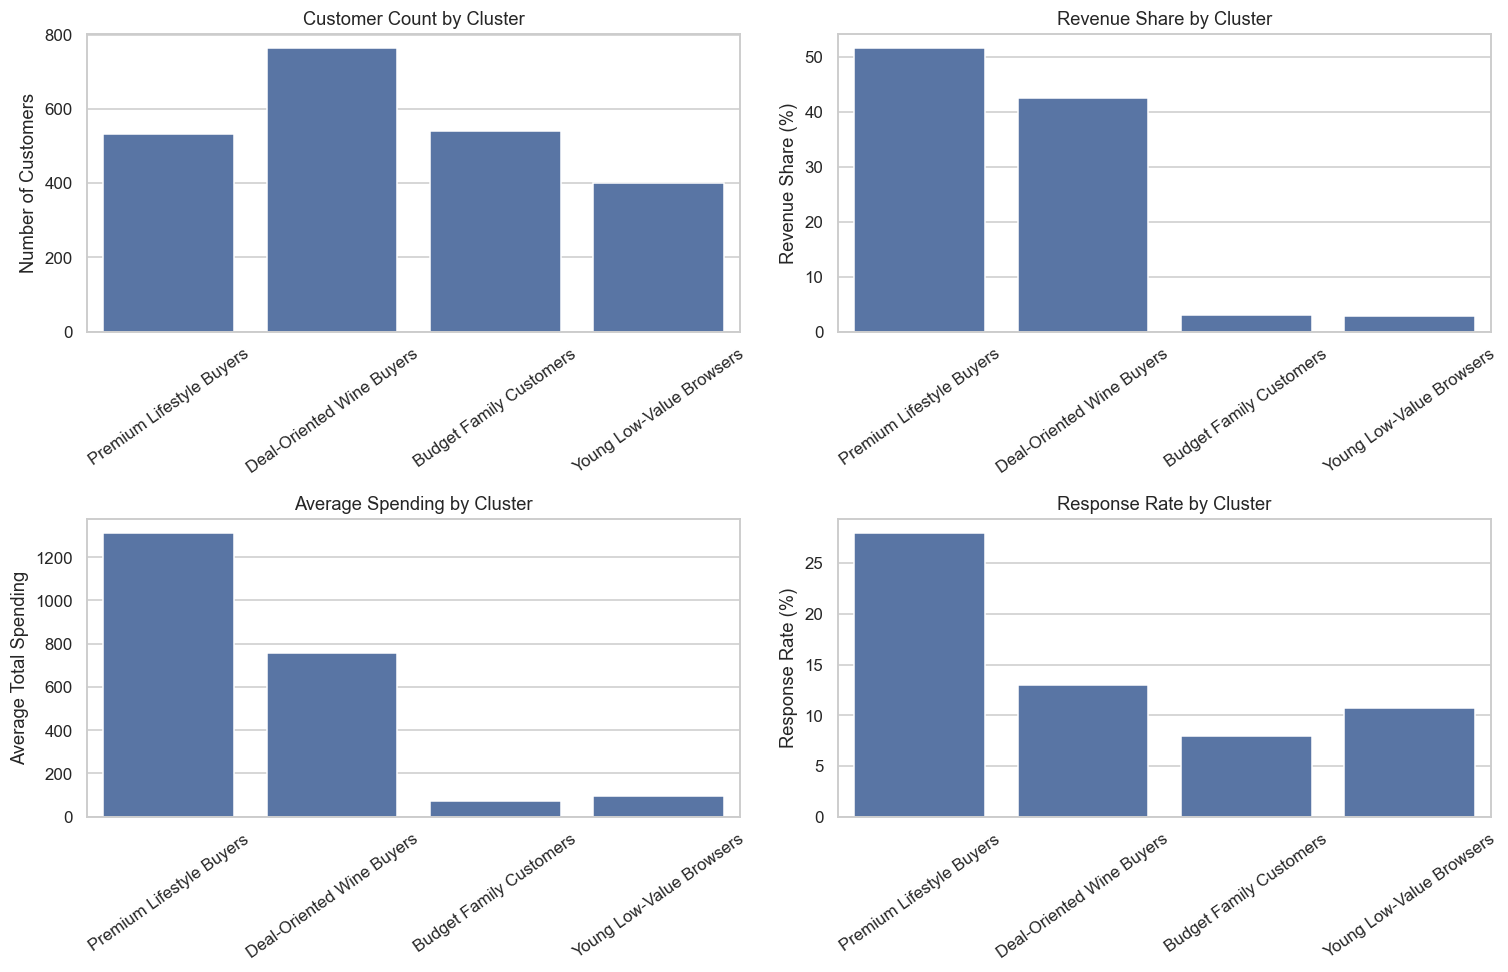

In [72]:
# Order clusters by revenue contribution to make the charts more business-readable
cluster_order = (
    cluster_profile
    .sort_values("Revenue_Share_%", ascending=False)["Cluster_Name"]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.barplot(
    data=cluster_profile,
    x="Cluster_Name",
    y="Customer_Count",
    order=cluster_order,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Customer Count by Cluster")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Number of Customers")
axes[0, 0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=cluster_profile,
    x="Cluster_Name",
    y="Revenue_Share_%",
    order=cluster_order,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Revenue Share by Cluster")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Revenue Share (%)")
axes[0, 1].tick_params(axis="x", rotation=35)

sns.barplot(
    data=cluster_profile,
    x="Cluster_Name",
    y="Avg_Total_Spending",
    order=cluster_order,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Average Spending by Cluster")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Average Total Spending")
axes[1, 0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=cluster_profile,
    x="Cluster_Name",
    y="Response_Rate_%",
    order=cluster_order,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Response Rate by Cluster")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Response Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

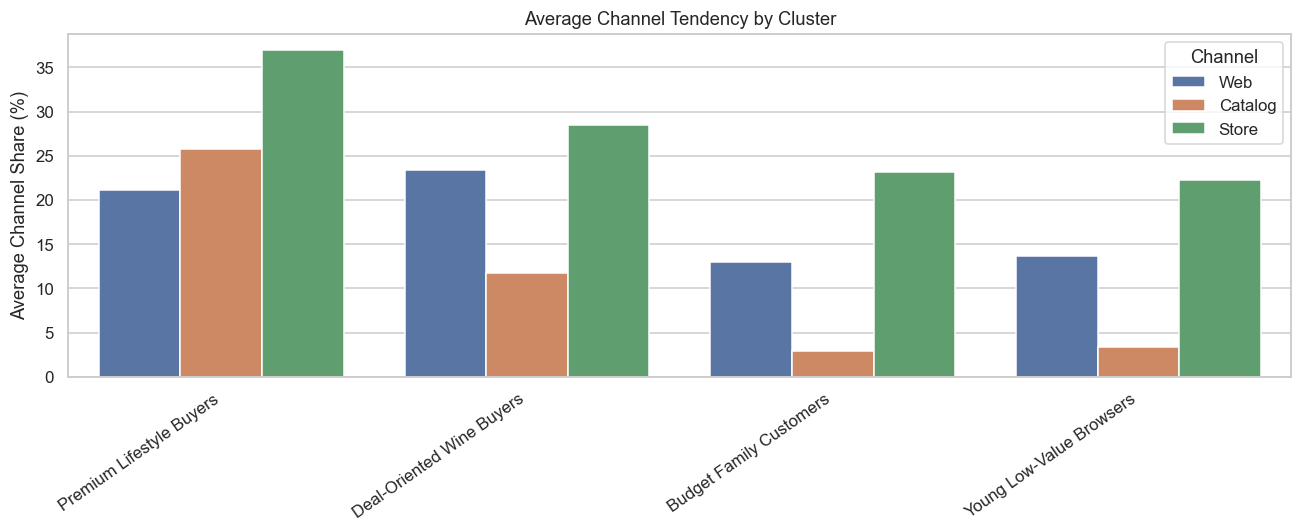

In [73]:
# Channel tendency by cluster
channel_plot = cluster_channel_profile.melt(
    id_vars=["Cluster", "Cluster_Name"],
    value_vars=["Avg_Web_Share_%", "Avg_Catalog_Share_%", "Avg_Store_Share_%"],
    var_name="Channel",
    value_name="Average_Share_%"
)

channel_plot["Channel"] = (
    channel_plot["Channel"]
    .str.replace("Avg_", "", regex=False)
    .str.replace("_Share_%", "", regex=False)
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=channel_plot,
    x="Cluster_Name",
    y="Average_Share_%",
    hue="Channel",
    order=cluster_order
)

plt.title("Average Channel Tendency by Cluster")
plt.xlabel("")
plt.ylabel("Average Channel Share (%)")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Channel")
plt.tight_layout()
plt.show()

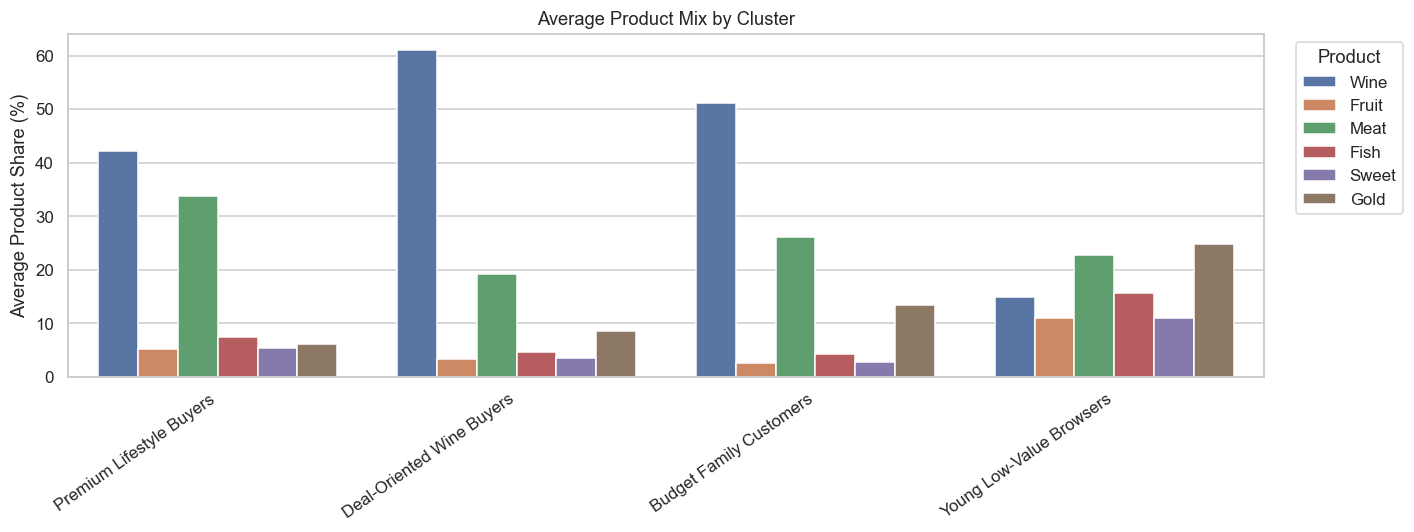

In [74]:
# Product mix by cluster
product_plot = cluster_product_profile.melt(
    id_vars=["Cluster", "Cluster_Name"],
    value_vars=[
        "Avg_Wine_Share_%",
        "Avg_Fruit_Share_%",
        "Avg_Meat_Share_%",
        "Avg_Fish_Share_%",
        "Avg_Sweet_Share_%",
        "Avg_Gold_Share_%"
    ],
    var_name="Product",
    value_name="Average_Share_%"
)

product_plot["Product"] = (
    product_plot["Product"]
    .str.replace("Avg_", "", regex=False)
    .str.replace("_Share_%", "", regex=False)
)

plt.figure(figsize=(13, 5))
sns.barplot(
    data=product_plot,
    x="Cluster_Name",
    y="Average_Share_%",
    hue="Product",
    order=cluster_order
)

plt.title("Average Product Mix by Cluster")
plt.xlabel("")
plt.ylabel("Average Product Share (%)")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Product", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

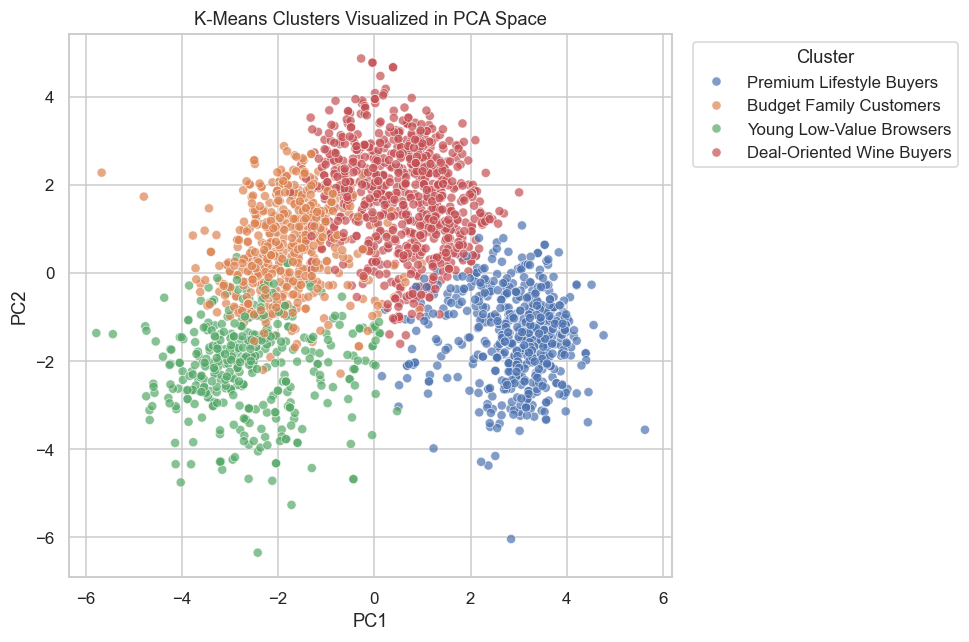

Explained variance by PC1 and PC2: 44.22%


In [75]:
from sklearn.decomposition import PCA

# PCA is used only for visualization, not for fitting the clustering model
pca = PCA(n_components=2, random_state=42)
cluster_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": cluster_pca[:, 0],
    "PC2": cluster_pca[:, 1],
    "Cluster_Name": df_cluster["Cluster_Name"]
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster_Name",
    alpha=0.7
)

plt.title("K-Means Clusters Visualized in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Explained variance by PC1 and PC2: {pca.explained_variance_ratio_.sum():.2%}")

**Cluster visualization — interpretation**

The visual profiles confirm that K-Means identifies **4 distinct customer personas**, each with different value, product and behavioral characteristics.

- `Premium Lifestyle Buyers` are the strongest premium segment: they show the highest average spending, strongest response rate, highest income and a product mix oriented toward Wines and Meat. This cluster is the best candidate for personalized premium communication.

- `Deal-Oriented Wine Buyers` generate a large revenue share and are strongly wine-oriented. They are commercially relevant, but their higher deal orientation suggests that they may respond better to targeted offers than to purely exclusive messaging.

- `Budget Family Customers` show lower spending and weaker revenue contribution. Their profile suggests more constrained purchasing behavior, so they should be addressed with practical, value-oriented communication rather than premium campaigns.

- `Young Low-Value Browsers` are low-spending and more digitally active, making them more suitable for low-cost nurturing, conversion-focused messages or digital retargeting.

The PCA plot is used only as a visualization tool: the K-Means model was fitted on the full standardized feature set, while PCA reduces the data to two dimensions to make the cluster structure easier to inspect. Some overlap is expected because customer behavior is multidimensional, but the plot still helps show that the clusters occupy reasonably different areas of the feature space.

### D.7 Compare K-Means clusters with RFM segments

This section compares the K-Means personas with the RFM segments created in Task C.

The goal is to understand whether the two methods identify similar customer groups or whether clustering captures additional behavioral and demographic patterns beyond recency, frequency and monetary value.

In [76]:
from sklearn.metrics import adjusted_rand_score

# Keep only records with both cluster and RFM segment labels
comparison_df = df_cluster.dropna(subset=["Cluster_Name", "RFM_Segment"]).copy()

# Count overlap between K-Means clusters and RFM segments
cluster_rfm_counts = pd.crosstab(
    comparison_df["Cluster_Name"],
    comparison_df["RFM_Segment"]
)

display(cluster_rfm_counts)

RFM_Segment,Champions,Hibernating Low Value,High Value At Risk,Loyal Big Spenders,Promising Recent Customers,Regular Customers
Cluster_Name,,,,,,
Budget Family Customers,0,179,0,0,215,145
Deal-Oriented Wine Buyers,147,4,14,230,64,305
Premium Lifestyle Buyers,108,3,93,162,15,152
Young Low-Value Browsers,2,120,0,1,159,119


In [77]:
# Row percentages show the internal RFM composition of each cluster
cluster_rfm_percent = pd.crosstab(
    comparison_df["Cluster_Name"],
    comparison_df["RFM_Segment"],
    normalize="index"
) * 100

display(cluster_rfm_percent.round(2))

RFM_Segment,Champions,Hibernating Low Value,High Value At Risk,Loyal Big Spenders,Promising Recent Customers,Regular Customers
Cluster_Name,,,,,,
Budget Family Customers,0.00,33.21,0.00,0.00,39.89,26.90
Deal-Oriented Wine Buyers,19.24,0.52,1.83,30.10,8.38,39.92
Premium Lifestyle Buyers,20.26,0.56,17.45,30.39,2.81,28.52
Young Low-Value Browsers,0.50,29.93,0.00,0.25,39.65,29.68


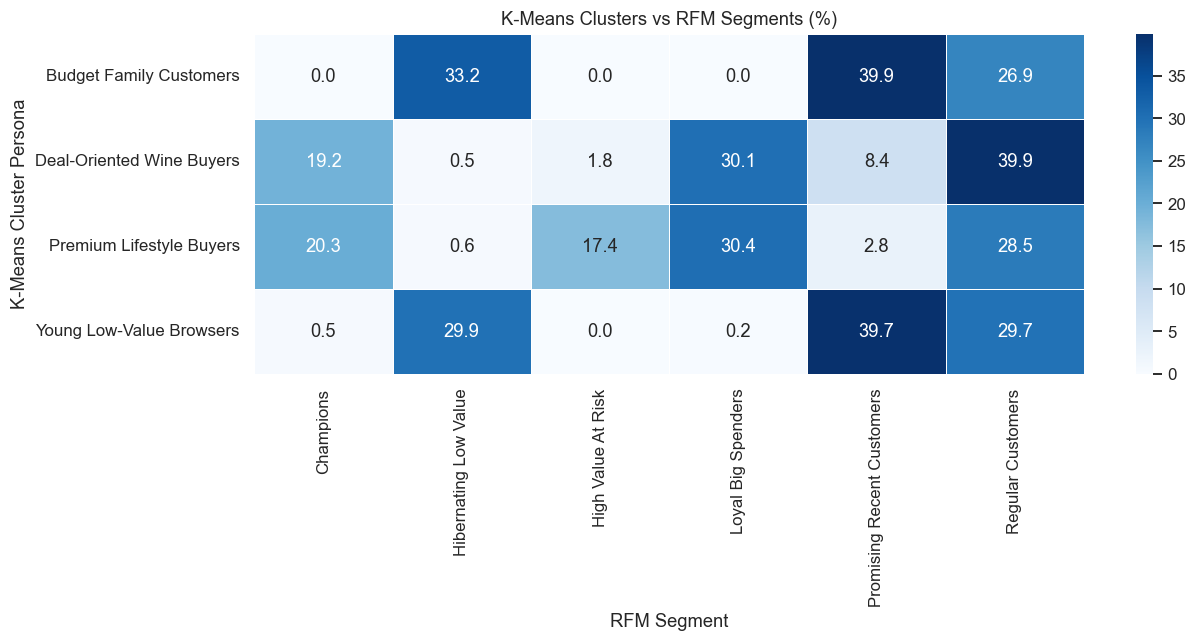

In [78]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_rfm_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("K-Means Clusters vs RFM Segments (%)")
plt.xlabel("RFM Segment")
plt.ylabel("K-Means Cluster Persona")
plt.tight_layout()
plt.show()

In [79]:
# Adjusted Rand Index measures agreement between the two segmentations
ari_score = adjusted_rand_score(
    comparison_df["RFM_Segment"],
    comparison_df["Cluster_Name"]
)

print(f"Adjusted Rand Index between RFM segments and K-Means clusters: {ari_score:.3f}")

Adjusted Rand Index between RFM segments and K-Means clusters: 0.129


In [80]:
# Summarize the dominant RFM segment inside each K-Means cluster
dominant_rfm_by_cluster = (
    cluster_rfm_percent
    .idxmax(axis=1)
    .reset_index(name="Dominant_RFM_Segment")
)

dominant_rfm_by_cluster["Dominant_RFM_Share_%"] = (
    cluster_rfm_percent.max(axis=1).values
).round(2)

display(dominant_rfm_by_cluster)

,Cluster_Name,Dominant_RFM_Segment,Dominant_RFM_Share_%
0,Budget Family Customers,Promising Recent Customers,39.89
1,Deal-Oriented Wine Buyers,Regular Customers,39.92
2,Premium Lifestyle Buyers,Loyal Big Spenders,30.39
3,Young Low-Value Browsers,Promising Recent Customers,39.65


### D.8 Task D Interpretation

K-Means clustering was applied to segment customers using a broader set of behavioral, demographic, channel and product-preference variables. Before fitting the model, skewed variables were log-transformed and all features were standardized, because K-Means is distance-based and sensitive to variable scale.

The optimal number of clusters was selected using the Elbow Method and Silhouette Score. Although a smaller number of clusters showed slightly stronger compactness, **k = 4** was selected as the best compromise between statistical quality and business interpretability.

The model produced four actionable customer personas: `Premium Lifestyle Buyers`, `Deal-Oriented Wine Buyers`, `Budget Family Customers` and `Young Low-Value Browsers`.

The comparison with RFM shows only **partial overlap** between the two approaches, confirmed by an Adjusted Rand Index of **0.129**. This means that RFM and K-Means are complementary rather than interchangeable.

Overall, **RFM helps decide who should be prioritized**, while **K-Means helps understand what type of customer they are and how communication should be adapted**. This distinction will support Task E, where communication channel and message tone are defined for the key customer segments.

---------------

## Task E — Communication Strategy

The previous tasks identified different but complementary segmentation perspectives.  
RFM segmentation shows **which customers should be prioritized** based on recency, frequency and monetary value, while K-Means clustering explains **how customers differ** in lifestyle, channel preference, product mix and deal sensitivity.

For this reason, the communication strategy combines both approaches: RFM defines commercial priority, while K-Means refines the recommended channel, tone and campaign message.

### E.1 Communication strategy logic

| Strategic Level | Main Segments | Communication Objective | Budget Priority |
|---|---|---|---|
| Premium retention | `Champions`, `Loyal Big Spenders`, `Premium Lifestyle Buyers` | Protect high-value customers and reinforce loyalty | High |
| Premium reactivation | `High Value At Risk` | Recover valuable customers before they become inactive | High |
| Growth and conversion | `Promising Recent Customers`, `Deal-Oriented Wine Buyers` | Increase repeat purchase and develop customer value | Medium |
| Digital nurturing | `Young Low-Value Browsers` | Convert browsing interest into purchase behavior | Medium-low |
| Low-cost maintenance | `Regular Customers`, `Budget Family Customers`, `Hibernating Low Value` | Maintain contact with scalable, low-cost communication | Low |

This logic avoids treating all customers equally. High-value and responsive groups receive more personalized and premium communication, while lower-value groups are managed through cheaper and more automated channels.

### E.2 Communication channel and message tone by segment

| Communication Group | Segments Included | Recommended Channel | Message Tone | Campaign Direction | Rationale |
|---|---|---|---|---|---|
| Premium Lifestyle Retention | `Premium Lifestyle Buyers`, `Premium Lifestyle Segment`, `Champions` | Personalized email, curated catalog-style communication, private store invitation | Exclusive, aspirational, appreciative | Curated **Wine + Meat premium selection**, early access, private preview, loyalty benefits | This is the strongest high-value and highly responsive audience. Catalog is over-represented in this group, and the product mix supports a premium Wine + Meat offer rather than a generic promotion. |
| Loyal High-Value Growth | `Loyal Big Spenders` | Personalized email, catalog recommendations, loyalty program communication | Premium, relationship-based, curated | Cross-sell bundles, preferred-category recommendations, loyalty status upgrade | These customers generate a large share of revenue and should be protected through recognition and personalized product discovery. |
| High-Value Reactivation | `High Value At Risk` | Personalized email, direct contact for top accounts, catalog reminder | Warm, personal, reassuring | “We miss you” message, limited-time premium incentive, early access to preferred categories | These customers have high monetary value but weaker recency. The objective is to reactivate them before their value is lost. |
| Deal-Oriented Growth | `Deal-Oriented Wine Buyers` | Email newsletter, selective catalog offers, store activation | Smart, practical, value-oriented | Controlled Wine bundles, loyalty multipliers, selective discounts | This group is commercially relevant but more promotion-sensitive. Offers should be selective to avoid weakening premium positioning. |
| Promising Recent Development | `Promising Recent Customers` | Onboarding email sequence, website recommendations, personalized follow-up | Welcoming, educational, encouraging | Second-purchase incentive, product discovery journey, starter bundles | These customers are recent but not yet high-frequency or high-spending. The goal is to build habits and increase lifetime value. |
| Digital Conversion | `Young Low-Value Browsers` | Website retargeting, simple email reminders, digital nudges | Clear, practical, friction-reducing | Abandoned-cart reminder, easier purchase path, entry-level bundle, free-shipping threshold | These customers show digital activity but low spending. The message should reduce barriers to purchase rather than promote exclusivity. |
| Low-Cost Maintenance | `Regular Customers`, `Budget Family Customers`, `Hibernating Low Value` | Automated email, seasonal newsletter, basic promotions | Simple, promotional, low-pressure | Seasonal offers, value bundles, light reactivation | These groups are larger or lower-value, so communication should remain scalable and cost-efficient. |

### E.3 Recommended main campaign

The strongest campaign opportunity is the **Premium Lifestyle Retention Campaign**.

The target should be customers without children in the household and with income above the 75th percentile, especially those who also belong to high-value RFM segments such as `Champions` and `Loyal Big Spenders`.

The campaign should use a **personalized premium email supported by catalog-style content**, because catalog-preferring customers showed high spending and high responsiveness. The message should be exclusive and curated, not discount-driven.

Recommended message concept:

**“A private selection created for your table: early access to our premium Wine & Meat collection.”**

The campaign should highlight:
- curated Wine + Meat pairings;
- early access to seasonal premium products;
- loyalty recognition or private preview;
- limited availability, without relying on aggressive discounts.

### E.4 Final recommendation

The communication strategy should not be based on one segmentation method only.

RFM segmentation identifies commercial priority: `Champions`, `Loyal Big Spenders` and `High Value At Risk` deserve the highest attention because they concentrate a large share of revenue.

K-Means clustering adds personalization: it shows whether customers are premium lifestyle buyers, deal-oriented wine buyers, budget family customers or digital low-value browsers. This determines the right channel and tone.

Overall, the recommended approach is:

**Use RFM to decide who to prioritize, and use K-Means to decide how to communicate with them.**

This creates a strategy that is both value-driven and behaviorally targeted.